# The quantum autoencoder — compressing quantum data with a variational circuit

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien)

*Quantum Many-Body Simulation — Chapter 11 — Variational quantum circuits*

## 1. Introduction and motivation

A classical autoencoder is a neural network trained to reproduce its own input through a narrow middle layer. If it
succeeds, the narrow layer is a *compressed* description of the data: whatever the network can reconstruct must have
been representable in the smaller space. A **quantum autoencoder** (Romero, Olson and Aspuru-Guzik, 2017) does the
same for quantum states, and the "narrow layer" is a smaller number of qubits.

The construction is short enough to state now. A unitary $U(\boldsymbol\theta)$ acts on $N$ qubits. Afterwards the
last $k$ qubits — the **trash** — are discarded and replaced by fresh $\vert0\rangle$'s, and $U^\dagger(\boldsymbol\theta)$
is applied to what remains. Nothing has been lost if and only if the encoder put the trash qubits *exactly* in
$\vert0\cdots0\rangle$ in the first place, because then discarding them removes nothing. Training the encoder to do
that for every state of a given family is the whole algorithm, and it compresses $N$ qubits into $N-k$.

The question worth asking is not "does it work" but **"what exactly can be compressed, and how well"**. That question
has a complete answer, which this notebook derives and then checks against what training actually achieves:

$$\boxed{\ \max_{U}\ \overline{F}_{\rm trash}\;=\;\sum_{a=1}^{2^{N-k}}\lambda_a^{\downarrow}\bigl(\bar\rho\bigr)\ }$$

the sum of the $2^{N-k}$ largest eigenvalues of the *ensemble-averaged* density matrix $\bar\rho$. Everything follows
from it: a single pure state is always compressible (its $\bar\rho$ has rank one), an ensemble is compressible exactly
as far as its spectrum allows, and whatever the trained circuit fails to reach is a limitation of the **ansatz**, not
of the task.

**Road map.**

* **Section 3** builds the encoder, the trash register and the decoder, and defines perfect compression.
* **Section 4** introduces the two cost functions — the **trash fidelity**, which needs no decoder and is what one
  trains on, and the **reconstruction fidelity**, which is what one cares about — and derives the exact relation
  $F_{\rm rec}=F_{\rm trash}\,\langle\chi\vert\rho_L\vert\chi\rangle$ between them, with the bounds
  $F_{\rm trash}^2\le F_{\rm rec}\le F_{\rm trash}$. Both are verified numerically.
* **Section 5** runs the compression channel two ways: **exactly**, as a partial trace over the trash followed by
  re-initialisation on the density tensor, and **stochastically**, by measuring the trash qubits and resetting them.
  The two agree within error bars, and the second is what a device does.
* **Section 6** proves the eigenvalue criterion above and applies it to four families of states.
* **Section 7** trains the encoder with `jax.grad` and Adam over a grid of families, compression ratios and depths,
  and compares what is reached with the bound. **Section 8** answers the question that comparison raises — whether a
  shortfall is the optimiser's fault or the circuit's — with two diagnostics. **Section 9** re-examines the folklore
  that "GHZ and W states are easy and Dicke states are hard" in the light of the criterion.
* **Section 10** trains on trajectory-estimated costs with SPSA — the device-realistic version.
* **Section 11** tests **generalisation**: train on a few members of a family, then measure the compression of
  members never seen.
* **Section 12** puts gate noise into the encoder, reusing the model of
  [44 — noisy variational circuits](../ch11_variational_quantum_circuits/44_noisy_variational_circuits.ipynb).

### What you will learn

*Physics*

* what "compressing quantum data" means and why it is a statement about an *ensemble*, not about one state;
* why the rank and the spectrum of $\bar\rho$ — not the entanglement of the individual states — decide
  compressibility;
* why a cost function measured only on the trash qubits controls the fidelity of the full reconstruction;
* how discarding a subsystem, measuring it and resetting it are the same channel.

*Numerical methods*

* the Ky Fan argument that turns "maximise over all unitaries" into "sum the largest eigenvalues";
* separating an information-theoretic bound from what a restricted ansatz can reach, by measuring both;
* validating a stochastic implementation against an exact one with binomial and mean-based error bars.

*Implementation practice*

* writing a cost so that a whole grid — four ensembles, four compression ratios, eight random starts — compiles into
  **one** program: the ensemble enters through the eigen-decomposition of $\bar\rho$, and the number of trash qubits
  through a traced index into a precomputed mask;
* `lax.scan` over circuit layers, and the inverse circuit written as a scan over the reversed parameter array;
* mid-circuit measurement and reset inside `vmap` with `measure_qubit` and `reset_qubit`.

### Prerequisites

* [06 — states, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb):
  reduced density matrices, Schmidt decomposition, fidelity;
* [07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb):
  the density tensor, partial trace, channels;
* [08 — measurements](../ch03_matrix_free_engine/08_measurements.ipynb): `measure_qubit`, `reset_qubit`, sampling and
  error bars;
* [40 — parametrized gates and gradients](../ch11_variational_quantum_circuits/40_parametrized_gates_and_gradients.ipynb)
  and [41 — optimisers](../ch11_variational_quantum_circuits/41_optimizers.ipynb): the ansatz, `jax.grad`, Adam, SPSA,
  the `lax.scan` training loop;
* [44 — noisy variational circuits](../ch11_variational_quantum_circuits/44_noisy_variational_circuits.ipynb) for
  Section 12.

**Conventions and sizes.** $N=6$ qubits throughout, with the trash register always the **last** $k$ qubits and
$k\le4$; the noise study of Section 12 drops to $N=4$ so that the density tensor stays cheap. The encoder is the
hardware-efficient ansatz of notebook 40 with $L$ layers and $n=2N(L+1)$ angles.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and notebook helpers

The autoencoder needs the ansatz gates, the partial trace in both of its forms (`rdm` for pure states, `rdm_dm` for
density tensors), mid-circuit measurement and reset, fidelity, and — for Section 12 — the channel primitives.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP  (auto-generated from quantum_engine.py -- derived step by step in Part 0)
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
P0 = jnp.array([[1, 0], [0, 0]], dtype=CDTYPE)  # projector |0><0|
P1 = jnp.array([[0, 0], [0, 1]], dtype=CDTYPE)  # projector |1><1|
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))
def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)

def rz(theta):
    """Rotation about z:  Rz(theta) = exp(-i theta Z/2) = diag(e^{-i theta/2}, e^{+i theta/2})."""
    e = jnp.exp(-0.5j * theta)
    return jnp.array([[e, 0], [0, jnp.conj(e)]], dtype=CDTYPE)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "Ab,abc->aAc"          A = new (output) index of qubit 1
        N=4, q=(1,3)    :  "ABbd,abcd->aAcB"      A,B = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter; U carries (new letters)+(old letters of the targets); the output is psi's
    labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; m = Kraus index, summed!)
        "mAa, mBc, abcd -> AbBd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

def basis_state(bits):
    """Computational basis state |b_0 b_1 ... b_{N-1}> from a list of bits."""
    bits = tuple(int(b) for b in bits)
    return jnp.zeros((2,) * len(bits), dtype=CDTYPE).at[bits].set(1.0)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def dicke_state(N, k):
    """Symmetric Dicke state |D_N^k>: equal superposition of all basis states with exactly k ones.
    Implementation: mask of the flat indices with popcount == k, normalised by sqrt(binom(N,k))."""
    idx = np.arange(2 ** N)
    pop = np.array([bin(i).count("1") for i in idx])
    v = (pop == k).astype(np.complex128)
    return jnp.asarray(v / np.linalg.norm(v), dtype=CDTYPE).reshape((2,) * N)

def w_state(N):
    """W state = Dicke state with one excitation: (|10..0> + |01..0> + ... + |0..01>)/sqrt(N)."""
    return dicke_state(N, 1)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def rdm_dm(rho, keep):
    """Partial trace of a density TENSOR (rank 2N), keeping the qubits `keep`.

    MATH      rho_A[a,a'] = sum_b rho[a,b ; a',b]
    EINSUM    N=2, keep=(0,):  "abAb->aA"   -- the letter b is REPEATED inside one operand and absent
              from the output: that is a trace over that pair of axes.
    """
    keep = tuple(int(q) for q in keep)
    N = rho.ndim // 2
    ket = list(_LETTERS[:N])
    bra = [(_LETTERS[N + q] if q in keep else ket[q]) for q in range(N)]
    sub = f"{''.join(ket)}{''.join(bra)}->{''.join(ket[q] for q in keep)}{''.join(bra[q] for q in keep)}"
    return jnp.einsum(sub, rho).reshape(2 ** len(keep), 2 ** len(keep))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def purity(rho_mat):
    """Tr(rho^2): 1 for pure states, 1/d for the maximally mixed state in dimension d."""
    return jnp.real(jnp.trace(rho_mat @ rho_mat))

def von_neumann_entropy(rho_mat, base=2.0):
    """S(rho) = -Tr(rho log rho) = -sum_i lambda_i log lambda_i  (in bits for base=2).
    Eigenvalues are clipped at 1e-16 because 0*log(0) := 0 but log(0) = -inf numerically."""
    lam = jnp.clip(jnp.linalg.eigvalsh(rho_mat), 1e-16, None)
    return -jnp.sum(lam * jnp.log(lam)) / jnp.log(base)

def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)

def fidelity_pure(psi, phi):
    """F = |<psi|phi>|^2 between two pure states."""
    return jnp.abs(jnp.vdot(psi, phi)) ** 2


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U
def measure_qubit(key, psi, q, basis="Z"):
    """Projective measurement of qubit q in the eigenbasis of X, Y or Z.  Returns (outcome, post-state).

    MATH   Born rule      p(0) = <psi|P0_q|psi> = (rho_q)[0,0]          (only the 1-qubit RDM is needed)
           collapse       |psi> -> P_m|psi> / sqrt(p(m))
           other bases    measuring P = U^dag Z U  ==  rotate with U, measure Z, rotate back with U^dag
                          (X: U = H;   Y: U = H S^dag).
    outcome 0 <-> eigenvalue +1,   outcome 1 <-> eigenvalue -1.
    JAX    no Python `if` on random data: `jnp.where` selects the projector, so the function is
           jit/vmap-able (vmap over keys = many independent shots).
    """
    U = _BASIS_ROT[basis]
    psi = apply_gate(psi, U, [q])
    p0 = jnp.real(rdm(psi, [q])[0, 0])
    outcome = (jax.random.uniform(key) >= p0).astype(jnp.int32)
    proj = jnp.where(outcome == 0, P0, P1)
    psi = apply_gate(psi, proj, [q])
    psi = psi / jnp.linalg.norm(psi)
    return outcome, apply_gate(psi, U.conj().T, [q])

def reset_qubit(key, psi, q):
    """Active reset: measure qubit q in Z and apply X if the outcome was 1 -> qubit ends in |0>,
    disentangled from the rest (used in teleportation-like protocols, autoencoders, reservoirs)."""
    outcome, psi = measure_qubit(key, psi, q)
    return apply_gate(psi, jnp.where(outcome == 1, X, I2), [q])


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_depolarizing(p):
    """Depolarising channel  rho -> (1-p) rho + (p/3)(X rho X + Y rho Y + Z rho Z).
    Kraus: sqrt(1-p) 1, sqrt(p/3) X, sqrt(p/3) Y, sqrt(p/3) Z.   Bloch vector shrinks by 1 - 4p/3."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p / 3) * X, jnp.sqrt(p / 3) * Y, jnp.sqrt(p / 3) * Z])


# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
def hea_num_params(N, layers):
    """Number of angles of `hardware_efficient_ansatz`: (layers+1) rotation blocks x N qubits x 2 angles."""
    return 2 * N * (layers + 1)

def hardware_efficient_ansatz(theta, N, layers, entangler=CZ, periodic=False):
    """Hardware-efficient ansatz
        |psi(theta)> = R(theta_L) * prod_{l<L} [ ENT * R(theta_l) ] |0...0>,   R = prod_q Rz(.) Ry(.),
    ENT = a chain of CZ (or any 2-qubit gate).  `theta` is a flat vector of length 2N(L+1).
    The function is a pure map theta -> state, hence jit-able and differentiable end to end."""
    theta = theta.reshape(layers + 1, N, 2)
    psi = zero_state(N)
    for l in range(layers + 1):
        for q in range(N):
            psi = apply_gate(psi, ry(theta[l, q, 0]), [q])
            psi = apply_gate(psi, rz(theta[l, q, 1]), [q])
        if l < layers:
            for q in range(N - 1):
                psi = apply_gate(psi, entangler, [q, q + 1])
            if periodic and N > 2:
                psi = apply_gate(psi, entangler, [N - 1, 0])
    return psi


In [3]:
# ==============================================================================
# PLOT STYLE + the training machinery of notebook 41
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def mean_and_se(x):
    """Sample mean and standard error of the mean of a 1D array of independent samples."""
    x = np.asarray(x)
    return float(np.mean(x)), float(np.std(x, ddof=1) / np.sqrt(x.size))


def bands(hist):
    """Median and interquartile band of a batch of histories, shape (n_runs, n_steps) -> three curves."""
    h = np.asarray(hist)
    return np.percentile(h, 25, axis=0), np.median(h, axis=0), np.percentile(h, 75, axis=0)


def opt_adam(lr, b1=0.9, b2=0.999, eps=1e-8):
    """Adam as a pair (init, update) of pure functions -- the optimiser interface of notebook 41."""
    def init(theta):
        return (jnp.zeros_like(theta), jnp.zeros_like(theta))

    def update(theta, state, g, k):
        m, v = state
        m = b1 * m + (1 - b1) * g
        v = b2 * v + (1 - b2) * g ** 2
        return theta - lr * (m / (1 - b1 ** k)) / (jnp.sqrt(v / (1 - b2 ** k)) + eps), (m, v)

    return init, update


def train(theta0, key, grad_rule, opt, monitor, n_steps):
    """One training run compiled as a single `lax.scan` (notebook 41, Step 8)."""
    init_fn, update_fn = opt

    def body(carry, k):
        theta, state, key = carry
        key, sub = jax.random.split(key)
        theta, state = update_fn(theta, state, grad_rule(theta, sub, k), k)
        return (theta, state, key), monitor(theta)

    (theta, _, _), hist = lax.scan(body, (theta0, init_fn(theta0), key), jnp.arange(1, n_steps + 1))
    return theta, hist


def random_starts(n_runs, n_params, seed, scale=jnp.pi):
    """`n_runs` independent parameter vectors drawn uniformly from [-scale, scale]^n, plus one PRNG key each."""
    k1, k2 = jax.random.split(jax.random.PRNGKey(seed))
    return (jax.random.uniform(k1, (n_runs, n_params), minval=-scale, maxval=scale),
            jax.random.split(k2, n_runs))

## 3. The compression task

### 3.1 Encoder, latent register, trash register

Split the $N$ qubits into a **latent** register $L$ of $N-k$ qubits (here: qubits $0,\dots,N-k-1$) and a **trash**
register $T$ of $k$ qubits (the last $k$). The encoder is a unitary $U(\boldsymbol\theta)$ on all $N$ qubits. Applied
to an input state $\vert\psi\rangle$ it produces

$$\vert\varphi\rangle=U(\boldsymbol\theta)\,\vert\psi\rangle .\tag{1}$$

**Compression is perfect for $\vert\psi\rangle$** when $\vert\varphi\rangle$ factorises with the trash in its fiducial
state,

$$\vert\varphi\rangle=\vert\chi\rangle_L\otimes\vert0\cdots0\rangle_T ,\tag{2}$$

because then the $N-k$ qubits of $\vert\chi\rangle$ carry the entire state: the trash qubits can be thrown away,
stored as the classical statement "they were all zero", and recreated on demand.

### 3.2 The decoder and the two ways of re-initialising the trash

The decoder discards the trash, supplies fresh $\vert0\rangle$'s and undoes the encoder:

$$\rho_{\rm out}=U^\dagger(\boldsymbol\theta)\,
  \Bigl[\mathrm{Tr}_T\bigl(\vert\varphi\rangle\langle\varphi\vert\bigr)\otimes
  \vert0\cdots0\rangle\langle0\cdots0\vert_T\Bigr]\,U(\boldsymbol\theta).\tag{3}$$

Equation (3) describes a *channel*, not a unitary — $\rho_{\rm out}$ is generally mixed — and it can be realised in two
physically different ways which Section 5 shows are the same map:

* **discard**: trace out the trash qubits and tensor in $\vert0\rangle\langle0\vert$ (this is Eq. (3) literally);
* **measure and reset**: measure each trash qubit in the $Z$ basis, record the outcome, and flip it to
  $\vert0\rangle$ if it came out $\vert1\rangle$ (`reset_qubit`). This is what hardware does, and it also yields the
  compression diagnostic for free, since a perfectly compressed input gives the outcome $0$ on every trash qubit every
  time.

### 3.3 The circuit

The encoder is the hardware-efficient ansatz of notebook 40 applied to an arbitrary input state rather than to
$\vert0\cdots0\rangle$: $L$ repetitions of [$R_y(\theta)R_z(\theta)$ on every qubit, then a chain of $CZ$ gates],
followed by one final rotation block, giving $n=2N(L+1)$ angles. Writing the repeated layers as a `lax.scan` keeps the
compiled graph independent of $L$; the decoder is the same scan run over the reversed parameter array with
$R_y(\theta)^\dagger=R_y(-\theta)$, $R_z(\theta)^\dagger=R_z(-\theta)$ and $CZ^\dagger=CZ$.

In [4]:
# ==============================================================================
# STEP 1: the encoder, its inverse, and the trash-state fidelity
# ==============================================================================
# PARAMETERS
N_Q = 6            # total qubits
K_MAX = 4          # largest number of trash qubits studied (the trash is ALWAYS the last k qubits)
R_MAX = 20         # largest ensemble rank we will need (= binomial(6,3) for the Dicke family of Section 6)


def rot_block(psi, row, N):
    """One rotation block: Ry(theta) then Rz(theta) on every qubit."""
    for q in range(N):
        psi = apply_gate(psi, ry(row[q, 0]), [q])
        psi = apply_gate(psi, rz(row[q, 1]), [q])
    return psi


def ent_block(psi, N):
    """One entangling block: a chain of CZ gates on the nearest-neighbour bonds."""
    for q in range(N - 1):
        psi = apply_gate(psi, CZ, [q, q + 1])
    return psi


def encode(theta, psi, N, layers):
    """Encoder U(theta)|psi>: the hardware-efficient ansatz applied to an ARBITRARY input state.

    MATH  U(theta) = R(theta_L) prod_{l<L} [ ENT . R(theta_l) ],  R = prod_q Rz(.) Ry(.),  ENT = chain of CZ.
    JAX   the L repeated layers are a `lax.scan` over the rows of theta, so the traced graph does not grow with L.
    """
    th = theta.reshape(layers + 1, N, 2)
    psi, _ = lax.scan(lambda p, row: (ent_block(rot_block(p, row, N), N), None), psi, th[:layers])
    return rot_block(psi, th[layers], N)


def decode(theta, psi, N, layers):
    """Decoder U^dagger(theta)|psi>: every gate of `encode` reversed and inverted.

    IMPLEMENTATION  Ry(t)^dag = Ry(-t), Rz(t)^dag = Rz(-t), CZ^dag = CZ; the gate ORDER is reversed as well,
                    which for the scan means iterating over the reversed parameter rows.
    """
    th = theta.reshape(layers + 1, N, 2)

    def rot_dag(p, row):
        for q in range(N - 1, -1, -1):
            p = apply_gate(p, rz(-row[q, 1]), [q])
            p = apply_gate(p, ry(-row[q, 0]), [q])
        return p

    def ent_dag(p):
        for q in range(N - 2, -1, -1):
            p = apply_gate(p, CZ, [q, q + 1])
        return p

    psi = rot_dag(psi, th[layers])
    psi, _ = lax.scan(lambda p, row: (rot_dag(ent_dag(p), row), None), psi, th[:layers][::-1])
    return psi


# Mask that selects, for each k, the trash patterns equal to 0...0.  Index j runs over the last K_MAX qubits
# (least significant bits in C order), so "the last k bits of j are zero" is  j mod 2^k == 0.
TRASH_MASK = jnp.asarray(np.array([[1.0 if (j % 2 ** k == 0) else 0.0 for j in range(2 ** K_MAX)]
                                   for k in range(1, K_MAX + 1)]), dtype=RDTYPE)


def trash_fidelities(phi, k_max=K_MAX):
    """Vector [F_1, ..., F_{k_max}] with  F_k = <0^k| rho_T^{(k)} |0^k>  for the LAST k qubits.

    MATH   F_k = sum over the latent indices of |phi[latent, 0,...,0]|^2  -- the Born probability that a Z
           measurement of the last k qubits returns all zeros.
    IMPLEMENTATION  |phi|^2 reshaped to (2^{N-k_max}, 2^{k_max}); summing over the first index gives the
           marginal distribution of the last k_max qubits, and one matrix-vector product with TRASH_MASK
           returns ALL k at once.  This is what lets the number of trash qubits be a *traced* index later.
    COST   O(2^N).
    """
    p = jnp.abs(phi.reshape(-1, 2 ** k_max)) ** 2
    return TRASH_MASK @ jnp.sum(p, axis=0)


# --- CHECKPOINT: the encoder reproduces the engine ansatz, and the decoder inverts it ----------------
th_chk = jax.random.uniform(jax.random.PRNGKey(0), (hea_num_params(N_Q, 3),), minval=-jnp.pi, maxval=jnp.pi)
err_ansatz = max_abs(encode(th_chk, zero_state(N_Q), N_Q, 3) - hardware_efficient_ansatz(th_chk, N_Q, 3))
psi_rand = haar_state(jax.random.PRNGKey(1), N_Q)
err_inv = max_abs(decode(th_chk, encode(th_chk, psi_rand, N_Q, 3), N_Q, 3) - psi_rand)
print(f"encode(theta, |0..0>) vs the engine's hardware_efficient_ansatz : {err_ansatz:.2e}")
print(f"decode(encode(psi)) - psi for a Haar-random input               : {err_inv:.2e}")
assert err_ansatz < TOL and err_inv < TOL

# --- CHECKPOINT: trash_fidelities agrees with an explicit reduced density matrix ---------------------
phi_chk = encode(th_chk, psi_rand, N_Q, 3)
for k in range(1, K_MAX + 1):
    rho_T = rdm(phi_chk, tuple(range(N_Q - k, N_Q)))
    direct = float(jnp.real(rho_T[0, 0]))
    fast = float(trash_fidelities(phi_chk)[k - 1])
    print(f"  k = {k}:  <0^k|rho_T|0^k> from rdm = {direct:.12f}   from trash_fidelities = {fast:.12f}")
    assert abs(direct - fast) < TOL

encode(theta, |0..0>) vs the engine's hardware_efficient_ansatz : 0.00e+00
decode(encode(psi)) - psi for a Haar-random input               : 1.53e-16


  k = 1:  <0^k|rho_T|0^k> from rdm = 0.482823508520   from trash_fidelities = 0.482823508520
  k = 2:  <0^k|rho_T|0^k> from rdm = 0.312154644520   from trash_fidelities = 0.312154644520
  k = 3:  <0^k|rho_T|0^k> from rdm = 0.132402356690   from trash_fidelities = 0.132402356690


  k = 4:  <0^k|rho_T|0^k> from rdm = 0.080693092058   from trash_fidelities = 0.080693092058


## 4. Two cost functions, and the exact relation between them

### 4.1 The trash fidelity

The quantity a device can measure without ever running the decoder is

$$F_{\rm trash}(\boldsymbol\theta)=\bigl\langle0\cdots0\bigr\vert\,\rho_T\,\bigl\vert0\cdots0\bigr\rangle,
  \qquad \rho_T=\mathrm{Tr}_L\bigl(\vert\varphi\rangle\langle\varphi\vert\bigr)
  =\mathrm{Tr}_L\bigl(U\rho\,U^\dagger\bigr).\tag{4}$$

It is the probability that measuring all $k$ trash qubits in the $Z$ basis gives $0$ on every one of them — one
circuit, $k$ single-qubit measurements, no decoder, no ancillas. It equals $1$ exactly when Eq. (2) holds. This is the
cost Romero, Olson and Aspuru-Guzik proposed, and it is a **local** cost in the sense of notebook 40: it involves only
$k$ of the $N$ qubits.

### 4.2 The reconstruction fidelity, and why the trash fidelity controls it

What one actually cares about is how well the decoder reproduces the input,

$$F_{\rm rec}(\boldsymbol\theta)=\langle\psi\vert\rho_{\rm out}\vert\psi\rangle\tag{5}$$

with $\rho_{\rm out}$ from Eq. (3). The relation between Eqs. (4) and (5) is exact and short to derive. Write
$\Pi=\mathbb 1_L\otimes\vert0\cdots0\rangle\langle0\cdots0\vert_T$ for the projector onto "trash is all zero", so that
$F\equiv F_{\rm trash}=\langle\varphi\vert\Pi\vert\varphi\rangle$. Split $\vert\varphi\rangle$ accordingly:

$$\Pi\vert\varphi\rangle=\sqrt F\,\vert\chi\rangle_L\vert0\rangle_T,\qquad
  (\mathbb 1-\Pi)\vert\varphi\rangle=\sum_{t\neq0}\vert\xi_t\rangle_L\vert t\rangle_T,\tag{6}$$

with $\vert\chi\rangle$ normalised and $\sum_{t\neq0}\lVert\xi_t\rVert^2=1-F$. Tracing out the trash, the cross terms
vanish because $\langle t\vert0\rangle=0$ for $t\neq0$:

$$\rho_L=\mathrm{Tr}_T\vert\varphi\rangle\langle\varphi\vert
  =F\,\vert\chi\rangle\langle\chi\vert+\sigma,\qquad
  \sigma=\sum_{t\neq0}\vert\xi_t\rangle\langle\xi_t\vert,\qquad \mathrm{Tr}\,\sigma=1-F.\tag{7}$$

Now insert Eq. (3) into Eq. (5). The unitaries cancel, $\langle\psi\vert U^\dagger(\cdot)U\vert\psi\rangle
=\langle\varphi\vert(\cdot)\vert\varphi\rangle$, and the operator in the middle factorises as
$\rho_L\otimes\vert0\rangle\langle0\vert=(\rho_L\otimes\mathbb 1)\,\Pi=\Pi\,(\rho_L\otimes\mathbb 1)$, so

$$F_{\rm rec}=\langle\varphi\vert\Pi\,(\rho_L\otimes\mathbb 1)\,\Pi\vert\varphi\rangle
  =F\,\langle\chi,0\vert(\rho_L\otimes\mathbb 1)\vert\chi,0\rangle
  =F\,\langle\chi\vert\rho_L\vert\chi\rangle .\tag{8}$$

Substituting Eq. (7) for $\rho_L$ and using $\langle\chi\vert\chi\rangle=1$,

$$\boxed{\;F_{\rm rec}=F\bigl(F+\langle\chi\vert\sigma\vert\chi\rangle\bigr)\;}
  \qquad\Longrightarrow\qquad F^2\le F_{\rm rec}\le F,\tag{9}$$

since $0\le\langle\chi\vert\sigma\vert\chi\rangle\le\mathrm{Tr}\,\sigma=1-F$.

Equation (9) is the justification for training on the local cost. Near perfect compression it gives

$$1-F_{\rm rec}\;\le\;1-F^2=(1-F)(1+F)\;\le\;2\,(1-F),\tag{10}$$

so driving the trash infidelity to zero drives the reconstruction infidelity to zero at least as fast, up to a factor
of two. The reverse is also true, $1-F\le1-F_{\rm rec}$: the two are equivalent figures of merit, and the cheap one
may be used.

In [5]:
# ==============================================================================
# STEP 2: the compression channel as a partial trace plus re-initialisation, and the two fidelities
# ==============================================================================
def reset_trash_dm(rho, k):
    """rho -> Tr_T(rho) (x) |0..0><0..0|_T  for the LAST k qubits of a density TENSOR (rank 2N).

    MATH   the "discard and supply a fresh |0>" step of Eq. (3).
    EINSUM (N=3, k=1)  "abcABc->abAB": repeating the trash label c in the ket and bra slots of ONE operand traces
           over it; the remaining latent labels stay open.  The |0><0| factor is then attached by an outer product
           and the axes are permuted back into (ket_0..ket_{N-1}, bra_0..bra_{N-1}) order.
    """
    N = rho.ndim // 2
    nL = N - k
    ket, bra = list(_LETTERS[:N]), list(_LETTERS[N:2 * N])
    sub_in = "".join(ket) + "".join(ket[q] if q >= nL else bra[q] for q in range(N))
    sub_out = "".join(ket[:nL]) + "".join(bra[:nL])
    traced = jnp.einsum(f"{sub_in}->{sub_out}", rho)                       # rho_L, rank 2(N-k)
    zero_T = jnp.zeros((2,) * (2 * k), dtype=rho.dtype).at[(0,) * (2 * k)].set(1.0)
    full = jnp.tensordot(traced, zero_T, axes=0)                           # axes: ketL, braL, ketT, braT
    perm = [0] * (2 * N)
    for i in range(nL):
        perm[i], perm[N + i] = i, nL + i
    for i in range(k):
        perm[nL + i], perm[N + nL + i] = 2 * nL + i, 2 * nL + k + i
    return jnp.transpose(full, perm)


def decode_dm(theta, rho, N, layers):
    """Apply U^dagger to a density tensor: V rho V^dagger with V = U^dagger, gate by gate in reverse order."""
    th = theta.reshape(layers + 1, N, 2)

    def rot_dag(r, row):
        for q in range(N - 1, -1, -1):
            r = apply_gate_dm(r, rz(-row[q, 1]), [q])
            r = apply_gate_dm(r, ry(-row[q, 0]), [q])
        return r

    def ent_dag(r):
        for q in range(N - 2, -1, -1):
            r = apply_gate_dm(r, CZ, [q, q + 1])
        return r

    rho = rot_dag(rho, th[layers])
    for l in range(layers - 1, -1, -1):
        rho = rot_dag(ent_dag(rho), th[l])
    return rho


def overlap_with_pure(rho, psi):
    """F = <psi|rho|psi> for a density tensor rho (rank 2N) and a pure state psi (rank N)."""
    N = psi.ndim
    ket, bra = _LETTERS[:N], _LETTERS[N:2 * N]
    return jnp.real(jnp.einsum(f"{ket},{ket}{bra},{bra}->", jnp.conj(psi), rho, psi))


def autoencoder_exact(theta, psi, N, layers, k):
    """Full autoencoder pass on the density tensor: encode, discard+reset the trash, decode.
    Returns (trash fidelity, reconstruction fidelity)."""
    phi = encode(theta, psi, N, layers)
    F_tr = trash_fidelities(phi)[k - 1]
    rho_out = decode_dm(theta, reset_trash_dm(to_dm(phi), k), N, layers)
    return F_tr, overlap_with_pure(rho_out, psi)


# --- CHECKPOINT: Eqs. (8) and (9) against the density-tensor computation ------------------------------
K_CHK, L_CHK = 2, 3
F_tr, F_rec = autoencoder_exact(th_chk, psi_rand, N_Q, L_CHK, K_CHK)
phi_chk = encode(th_chk, psi_rand, N_Q, L_CHK)
chi = (phi_chk[(slice(None),) * (N_Q - K_CHK) + (0,) * K_CHK] / jnp.sqrt(F_tr)).reshape(-1)  # Eq. (6)
rho_L = rdm(phi_chk, tuple(range(N_Q - K_CHK)))                                             # Eq. (7)
formula = float(F_tr) * float(jnp.real(jnp.vdot(chi, rho_L @ chi)))
print(f"random theta, N = {N_Q}, L = {L_CHK}, k = {K_CHK}")
print(f"  F_trash                                   = {float(F_tr):.12f}")
print(f"  F_rec  (density tensor, Eq. 3)            = {float(F_rec):.12f}")
print(f"  F_trash * <chi|rho_L|chi>  (Eq. 8)        = {formula:.12f}")
print(f"  bounds of Eq. (9):  F^2 = {float(F_tr) ** 2:.6f}  <=  F_rec = {float(F_rec):.6f}  <=  F = {float(F_tr):.6f}")
assert abs(float(F_rec) - formula) < TOL
assert float(F_tr) ** 2 - TOL <= float(F_rec) <= float(F_tr) + TOL

random theta, N = 6, L = 3, k = 2
  F_trash                                   = 0.312154644520
  F_rec  (density tensor, Eq. 3)            = 0.115095845865
  F_trash * <chi|rho_L|chi>  (Eq. 8)        = 0.115095845865
  bounds of Eq. (9):  F^2 = 0.097441  <=  F_rec = 0.115096  <=  F = 0.312155


400 random encoders, k = 2: F_trash in [0.129, 0.431]
  every point satisfies F^2 <= F_rec <= F   : True
  distance above the lower bound F^2        : mean 0.0119, max 0.0374
  distance below the upper bound F          : mean 0.1743, min 0.1016


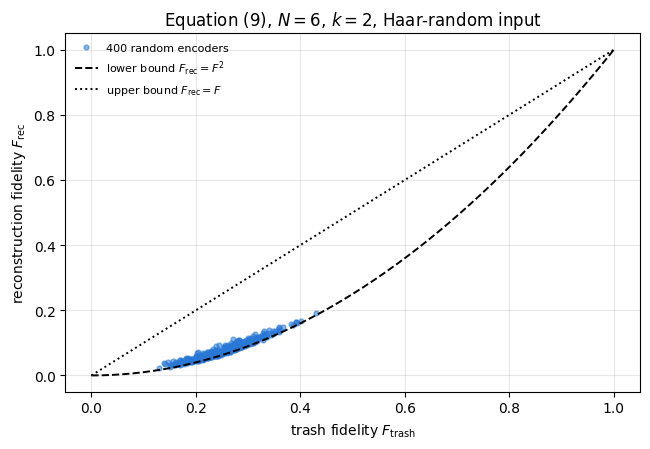

In [6]:
# ==============================================================================
# STEP 3: the two fidelities over 400 random encoders -- where the bounds are tight
# ==============================================================================
TH_SCAN = jax.random.uniform(jax.random.PRNGKey(21), (400, hea_num_params(N_Q, L_CHK)),
                             minval=-jnp.pi, maxval=jnp.pi)
pair = jax.jit(jax.vmap(lambda t: jnp.stack(autoencoder_exact(t, psi_rand, N_Q, L_CHK, K_CHK))))
FT, FR = np.asarray(jax.block_until_ready(pair(TH_SCAN))).T
resid = FR - FT ** 2
print(f"400 random encoders, k = {K_CHK}: F_trash in [{FT.min():.3f}, {FT.max():.3f}]")
print(f"  every point satisfies F^2 <= F_rec <= F   : {bool(np.all(FR >= FT ** 2 - 1e-12) and np.all(FR <= FT + 1e-12))}")
print(f"  distance above the lower bound F^2        : mean {resid.mean():.4f}, max {resid.max():.4f}")
print(f"  distance below the upper bound F          : mean {(FT - FR).mean():.4f}, min {(FT - FR).min():.4f}")

grid = np.linspace(0, 1, 200)
fig, ax = plt.subplots(figsize=(6.6, 4.6))
ax.plot(FT, FR, "o", ms=3.5, alpha=0.55, color=PALETTE[0], label="400 random encoders")
ax.plot(grid, grid ** 2, "k--", lw=1.4, label=r"lower bound $F_{\mathrm{rec}}=F^2$")
ax.plot(grid, grid, "k:", lw=1.4, label=r"upper bound $F_{\mathrm{rec}}=F$")
ax.set_xlabel(r"trash fidelity $F_{\mathrm{trash}}$"); ax.set_ylabel(r"reconstruction fidelity $F_{\mathrm{rec}}$")
ax.set_title(f"Equation (9), $N={N_Q}$, $k={K_CHK}$, Haar-random input")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

Equation (8) reproduces the density-tensor computation to twelve digits, and every one of the 400 random encoders
falls inside the band of Eq. (9). The scatter hugs the lower bound $F_{\rm rec}=F^2$: for a random encoder the
residual $\vert\varphi_\perp\rangle$ of Eq. (6) has essentially no overlap with $\vert\chi\rangle$ in the latent
register, so $\langle\chi\vert\sigma\vert\chi\rangle\approx0$ and Eq. (9) is nearly saturated from below.

The two bounds meet at $F=1$, which is the statement that matters for training: the only way to have
$F_{\rm rec}=1$ is to have $F_{\rm trash}=1$, and near that point the two infidelities differ by at most the factor of
two of Eq. (10). **Minimising the trash infidelity is not an approximation to minimising the reconstruction
infidelity; it is an equivalent problem, and it is the cheaper one.**

> **Numerical practice.** The cheap cost also has a better-behaved gradient: $F_{\rm trash}$ needs one circuit and $k$
> measurements, while $F_{\rm rec}$ needs the encoder, the reset and the decoder — twice the depth, and on hardware a
> swap test or a full tomography to read out the overlap. Whenever a local surrogate can be proved equivalent to the
> global quantity, use it.

## 5. Two executions of the same channel

The reset of Eq. (3) was implemented above as a partial trace. A device cannot trace; it measures. Measuring the
$k$ trash qubits in the $Z$ basis gives an outcome string $t$ with probability
$p_t=\langle\varphi\vert(\mathbb 1_L\otimes\vert t\rangle\langle t\vert)\vert\varphi\rangle$ and leaves the latent
register in $\vert\xi_t\rangle/\sqrt{p_t}$; applying $X$ to every trash qubit that returned $1$ puts the trash back in
$\vert0\rangle$. Averaging the resulting pure states over outcomes gives

$$\sum_t p_t\,\frac{\vert\xi_t\rangle\langle\xi_t\vert}{p_t}\otimes\vert0\rangle\langle0\vert
  =\Bigl(\sum_t\langle t\vert\varphi\rangle\langle\varphi\vert t\rangle\Bigr)\otimes\vert0\rangle\langle0\vert
  =\mathrm{Tr}_T\bigl(\vert\varphi\rangle\langle\varphi\vert\bigr)\otimes\vert0\rangle\langle0\vert,\tag{11}$$

which is exactly the operator in Eq. (3). **Discarding and measuring-then-resetting are the same channel**, and since
$F_{\rm rec}$ is linear in $\rho_{\rm out}$, the trajectory average of the per-shot reconstruction fidelity is
unbiased. The trash fidelity comes out of the same run at no extra cost: it is the probability that the recorded
outcome string is all zeros, estimated by a binomial proportion with standard error $\sqrt{F(1-F)/M}$.

The engine's `measure_qubit` and `reset_qubit` select the projector with `jnp.where` rather than a Python `if`, so one
trajectory is a pure function of its PRNG key and `vmap` runs $M$ of them in one compiled program.

4000 measure-and-reset trajectories, N = 6, L = 3, k = 2
  trash fidelity   exact 0.312155   trajectories 0.313750 +- 0.007337   (0.22 standard errors)
  reconstruction   exact 0.115096   trajectories 0.115584 +- 0.002132   (0.23 standard errors)


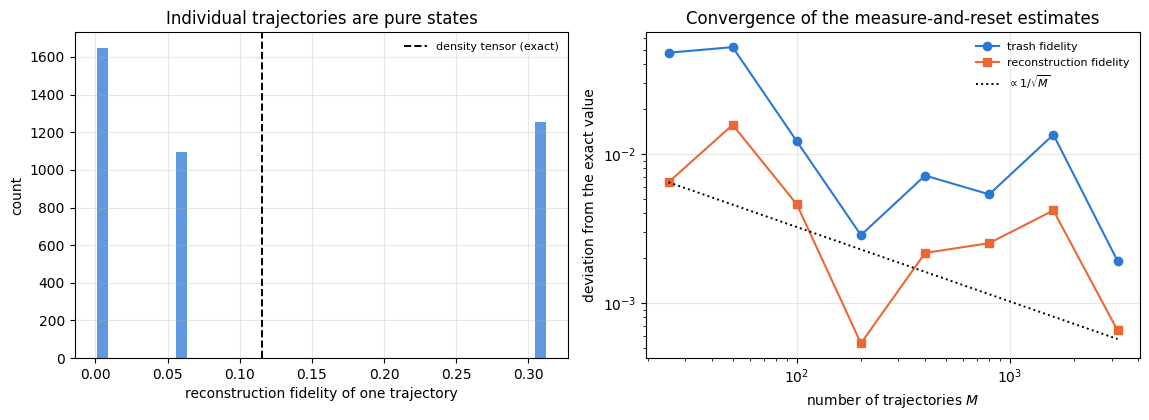

In [7]:
# ==============================================================================
# STEP 4: one trajectory of the autoencoder -- measure the trash, reset it, decode
# ==============================================================================
def autoencoder_trajectory(key, theta, psi, N, layers, k):
    """ONE stochastic run: encode, measure+reset each trash qubit, decode.

    Returns (outcomes of the k trash measurements, reconstruction fidelity of this run).
    JAX   `measure_qubit` uses `jnp.where` on the traced outcome, so the whole function is jit/vmap-able.
    COST  O(2^N) memory; M trajectories are embarrassingly parallel.
    """
    phi = encode(theta, psi, N, layers)
    outcomes = []
    for q in range(N - k, N):
        key, sub = jax.random.split(key)
        out, phi = measure_qubit(sub, phi, q)
        phi = apply_gate(phi, jnp.where(out == 1, X, I2), [q])        # reset: flip if the outcome was 1
        outcomes.append(out)
    return jnp.stack(outcomes), fidelity_pure(psi, decode(theta, phi, N, layers))


M_TRAJ_CHK = 4000
traj = jax.jit(jax.vmap(lambda kk: autoencoder_trajectory(kk, th_chk, psi_rand, N_Q, L_CHK, K_CHK)))
outs, fids = jax.block_until_ready(traj(jax.random.split(jax.random.PRNGKey(4), M_TRAJ_CHK)))
outs, fids = np.asarray(outs), np.asarray(fids)
all_zero = (outs.sum(axis=1) == 0)
F_tr_mc = all_zero.mean()
se_tr = np.sqrt(F_tr_mc * (1 - F_tr_mc) / M_TRAJ_CHK)
F_rec_mc, se_rec = mean_and_se(fids)
print(f"{M_TRAJ_CHK} measure-and-reset trajectories, N = {N_Q}, L = {L_CHK}, k = {K_CHK}")
print(f"  trash fidelity   exact {float(F_tr):.6f}   trajectories {F_tr_mc:.6f} +- {se_tr:.6f}   "
      f"({abs(F_tr_mc - float(F_tr)) / se_tr:.2f} standard errors)")
print(f"  reconstruction   exact {float(F_rec):.6f}   trajectories {F_rec_mc:.6f} +- {se_rec:.6f}   "
      f"({abs(F_rec_mc - float(F_rec)) / se_rec:.2f} standard errors)")
assert abs(F_tr_mc - float(F_tr)) < 5 * se_tr and abs(F_rec_mc - float(F_rec)) < 5 * se_rec

Ms = np.array([25, 50, 100, 200, 400, 800, 1600, 3200])
err_tr = np.array([abs(all_zero[:m].mean() - float(F_tr)) for m in Ms])
err_rec = np.array([abs(fids[:m].mean() - float(F_rec)) for m in Ms])
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.3))
axes[0].hist(fids, bins=40, color=PALETTE[0], alpha=0.75)
axes[0].axvline(float(F_rec), color="k", ls="--", lw=1.4, label="density tensor (exact)")
axes[0].set_xlabel("reconstruction fidelity of one trajectory"); axes[0].set_ylabel("count")
axes[0].set_title("Individual trajectories are pure states"); axes[0].legend(fontsize=8)
axes[1].loglog(Ms, np.maximum(err_tr, 1e-6), MARKERS[0] + "-", ms=6, color=PALETTE[0], label="trash fidelity")
axes[1].loglog(Ms, np.maximum(err_rec, 1e-6), MARKERS[1] + "-", ms=6, color=PALETTE[1],
               label="reconstruction fidelity")
axes[1].loglog(Ms, err_rec[0] * np.sqrt(Ms[0] / Ms), "k:", lw=1.4, label=r"$\propto1/\sqrt{M}$")
axes[1].set_xlabel("number of trajectories $M$"); axes[1].set_ylabel("deviation from the exact value")
axes[1].set_title("Convergence of the measure-and-reset estimates"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

The stochastic implementation reproduces both exact numbers within a fraction of a standard error, and the deviations
fall as $1/\sqrt M$. Equation (11) is therefore not only an algebraic identity: the two very different procedures —
an einsum that contracts a pair of tensor axes, and a sequence of random projections with feedback — describe the same
channel.

The histogram shows what is being averaged. Each trajectory is a pure state whose fidelity with the input takes one of
a small number of values (one per measurement outcome string), and the distribution is nothing like a narrow peak
around the mean. The density tensor delivers that mean directly; the trajectories deliver it with an error bar and a
memory cost of $2^N$ instead of $4^N$.

> **Physics insight.** Equation (11) is the statement that *an unread measurement is a channel*. The same identity
> underlies the dephasing channel of notebook 07 and the deferred-measurement principle: whether the outcome is looked
> at changes what one knows, not what the reduced state of the rest of the system is.

## 6. What can be compressed: an eigenvalue criterion

### 6.1 The averaged trash fidelity is a projector expectation

An autoencoder is trained on an **ensemble** $\{p_m,\vert\psi_m\rangle\}$, not on one state. The figure of merit is the
average trash fidelity. Using Eq. (4) and the cyclic property of the trace,

$$\overline F_{\rm trash}(U)=\sum_m p_m\langle\psi_m\vert U^\dagger\Pi\,U\vert\psi_m\rangle
  =\mathrm{Tr}\bigl(\bar\rho\;U^\dagger\Pi\,U\bigr),\qquad
  \bar\rho=\sum_mp_m\vert\psi_m\rangle\langle\psi_m\vert .\tag{12}$$

Two facts are already visible. First, **only $\bar\rho$ matters**: two ensembles with the same average density matrix
are equally compressible, and the individual states have disappeared from the problem. Second, $\Pi$ is an orthogonal
projector of rank $2^{N-k}$ (it fixes $k$ qubits and leaves $N-k$ free), so $P\equiv U^\dagger\Pi U$ is an orthogonal
projector of the same rank, and *every* rank-$2^{N-k}$ projector arises from some $U$.

### 6.2 The maximum, by a counting argument

Let $\bar\rho=\sum_a\lambda_a\vert a\rangle\langle a\vert$ with $\lambda_1\ge\lambda_2\ge\dots\ge\lambda_{2^N}\ge0$ and
write $m=2^{N-k}$. Then

$$\mathrm{Tr}(\bar\rho P)=\sum_a\lambda_a\,c_a,\qquad c_a\equiv\langle a\vert P\vert a\rangle .$$

The numbers $c_a$ are constrained: $0\le c_a\le1$ because $P$ is a projector ($\langle a\vert P\vert a\rangle
=\lVert P\vert a\rangle\rVert^2\le\lVert\vert a\rangle\rVert^2$), and $\sum_ac_a=\mathrm{Tr}\,P=m$. Maximising the
linear function $\sum_a\lambda_ac_a$ over that set is elementary: give weight $1$ to the $m$ largest $\lambda_a$ and
$0$ to the rest. The maximum is attained by the projector onto the span of the top $m$ eigenvectors, which is a
legitimate choice of $P$, so

$$\boxed{\;\max_{U}\ \overline F_{\rm trash}=\sum_{a=1}^{2^{N-k}}\lambda_a^{\downarrow}(\bar\rho)\;}\tag{13}$$

(a special case of Ky Fan's maximum principle). The encoder achieving it maps the $2^{N-k}$ dominant eigenvectors of
$\bar\rho$ into the subspace where the trash is $\vert0\cdots0\rangle$.

### 6.3 Three consequences

* **An ensemble supported on a subspace of dimension $r\le2^{N-k}$ is perfectly compressible**, because then
  $\lambda_a=0$ for $a>r$ and the sum in Eq. (13) is $1$. The relevant number is the **rank of $\bar\rho$**, not any
  property of the individual states.
* **A single pure state is always compressible, to any $k\le N-1$.** Its $\bar\rho$ has rank one, so Eq. (13) gives
  $1$ for every $m\ge1$. There is nothing to prove and nothing to discuss: one vector can be rotated onto one vector.
  Compression of a single state is a statement about *which unitary*, never about *whether*.
* **When $r>2^{N-k}$ the loss is quantified exactly**: the best possible average trash fidelity is the weight of the
  $2^{N-k}$ dominant eigenvectors, and $1-\overline F$ is the weight of the tail that must be thrown away.

### 6.4 Four families

We build ensembles with a continuous parameter, as a physical source would produce. Fix a set of $C$ computational
basis states $\{\vert s_j\rangle\}$ and amplitudes $a_j$ with $\sum_j a_j^2=1$, and let the family be

$$\vert\psi(\phi)\rangle=\sum_{j=0}^{C-1}a_j\,e^{\,\mathrm i j\phi}\,\vert s_j\rangle,\qquad \phi\in[0,2\pi).\tag{14}$$

Averaging over $\phi$ kills every off-diagonal element,
$\frac1{2\pi}\int_0^{2\pi}e^{\mathrm i(j-j')\phi}\mathrm d\phi=\delta_{jj'}$, so

$$\bar\rho=\sum_j a_j^2\,\vert s_j\rangle\langle s_j\vert,\tag{15}$$

of rank $C$ with spectrum $\{a_j^2\}$ — a spectrum we can design. Sampling $\phi$ on the uniform grid
$\phi_m=2\pi m/C$, $m=0,\dots,C-1$, reproduces Eq. (15) **exactly** rather than approximately, because
$\frac1C\sum_me^{\mathrm i(j-j')\phi_m}=\delta_{j\equiv j'\ (\mathrm{mod}\ C)}$ and $\vert j-j'\vert<C$. A finite
ensemble of $C$ members is thus an exact stand-in for the continuous family.

| family | support $\{\vert s_j\rangle\}$ | amplitudes | rank of $\bar\rho$ |
|---|---|---|---|
| GHZ | $\vert000000\rangle,\ \vert111111\rangle$ | equal | $2$ |
| W | the six states with one excitation | equal | $6$ |
| Dicke($3$) | the twenty states with three excitations | equal | $20$ |
| graded W | the six states with one excitation | $a_j^2\propto6-j$ | $6$ |

The first three are the families named in the folklore about compressibility; the fourth has the same support as the
second but a deliberately uneven spectrum, which is where Eq. (13) stops being a rank count and becomes a statement
about weights.

four ensembles on N = 6 qubits; the bound of Eq. (13) is the sum of the 2^(N-k) largest eigenvalues
          family  members  rank                largest eigenvalues       k=1     k=2     k=3     k=4
      GHZ family        2     2      0.500 0.500 0.000 0.000 0.000    1.0000  1.0000  1.0000  1.0000
        W family        6     6      0.167 0.167 0.167 0.167 0.167    1.0000  1.0000  1.0000  0.6667
 Dicke(3) family       20    20      0.050 0.050 0.050 0.050 0.050    1.0000  0.8000  0.4000  0.2000
        graded W        6     6      0.286 0.238 0.190 0.143 0.095    1.0000  1.0000  1.0000  0.8571

graded W: max |rho_avg(discrete grid) - rho_avg(continuous phi)| = 7.73e-17


Eq. (12) at a random theta (Dicke(3), k=2): ensemble average 0.246196587816, spectral form 0.246196587816, difference 2.8e-17


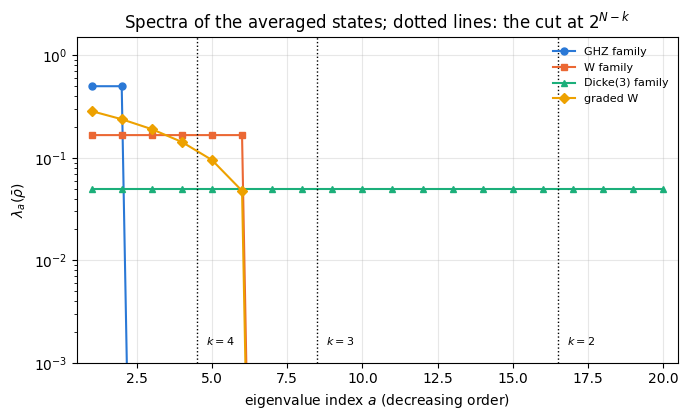

In [8]:
# ==============================================================================
# STEP 5: the four families, their averaged density matrices and the bound of Eq. (13)
# ==============================================================================
def phase_family(N, support, amplitudes=None):
    """The C members of the family of Eq. (14), sampled on the exact Fourier grid phi_m = 2 pi m / C.

    `support` is a list of C flat basis-state indices; `amplitudes` their (unnormalised) weights a_j.
    Returns an array of shape (C, 2, 2, ..., 2).
    """
    C = len(support)
    a = np.ones(C) if amplitudes is None else np.asarray(amplitudes, dtype=float)
    a = a / np.linalg.norm(a)
    out = np.zeros((C, 2 ** N), dtype=complex)
    for m in range(C):
        for j, s in enumerate(support):
            out[m, s] = a[j] * np.exp(2j * np.pi * j * m / C)
    return jnp.asarray(out.reshape((C,) + (2,) * N), dtype=CDTYPE)


def excitation_indices(N, w):
    """Flat indices of the computational basis states with exactly w excitations (bits equal to 1)."""
    return [i for i in range(2 ** N) if bin(i).count("1") == w]


def ensemble_spectrum(states, r_max=R_MAX):
    """Eigen-decomposition of rho_avg = (1/M) sum_m |psi_m><psi_m|, padded to exactly r_max terms.

    MATH   Eq. (12).  Returns (lambdas (r_max,), eigenvectors (r_max, 2,...,2)) sorted by decreasing lambda,
           with zero weights padding the unused slots.
    WHY    by Eq. (12) the cost depends on the ensemble ONLY through rho_avg, so carrying its spectrum lets
           ensembles of different sizes share one compiled program: they all become (r_max) weighted states.
    """
    M, N = states.shape[0], states.ndim - 1
    V = np.asarray(states).reshape(M, -1)
    rho = (V.conj().T @ V) / M
    lam, vec = np.linalg.eigh(rho)
    order = np.argsort(lam)[::-1][:r_max]
    lam, vec = lam[order], vec[:, order]
    pad = r_max - lam.size
    if pad > 0:
        lam = np.concatenate([lam, np.zeros(pad)])
        vec = np.concatenate([vec, np.zeros((vec.shape[0], pad))], axis=1)
    return (jnp.asarray(np.clip(lam, 0.0, None), dtype=RDTYPE),
            jnp.asarray(vec.T.reshape((r_max,) + (2,) * N), dtype=CDTYPE))


FAMILIES = {
    "GHZ family": phase_family(N_Q, [0, 2 ** N_Q - 1]),
    "W family": phase_family(N_Q, excitation_indices(N_Q, 1)),
    "Dicke(3) family": phase_family(N_Q, excitation_indices(N_Q, 3)),
    "graded W": phase_family(N_Q, excitation_indices(N_Q, 1), amplitudes=np.sqrt([6, 5, 4, 3, 2, 1])),
}
SPECTRA = {name: ensemble_spectrum(ens) for name, ens in FAMILIES.items()}
BOUND = {name: np.array([float(jnp.sum(SPECTRA[name][0][:2 ** (N_Q - k)])) for k in range(1, K_MAX + 1)])
         for name in FAMILIES}

print(f"four ensembles on N = {N_Q} qubits; the bound of Eq. (13) is the sum of the 2^(N-k) largest eigenvalues")
print(f"{'family':>16s} {'members':>8s} {'rank':>5s} {'largest eigenvalues':>34s}   " +
      " ".join(f"{('k=' + str(k)):>7s}" for k in range(1, K_MAX + 1)))
for name, ens in FAMILIES.items():
    lam = np.asarray(SPECTRA[name][0])
    rank = int(np.sum(lam > 1e-10))
    top = " ".join(f"{v:.3f}" for v in lam[:5])
    print(f"{name:>16s} {ens.shape[0]:8d} {rank:5d} {top:>34s}   " +
          " ".join(f"{BOUND[name][k - 1]:7.4f}" for k in range(1, K_MAX + 1)))

# --- CHECKPOINT: the discrete grid reproduces the continuous average of Eq. (15) ----------------------
cont = np.zeros((2 ** N_Q, 2 ** N_Q), dtype=complex)
supp, amps = excitation_indices(N_Q, 1), np.sqrt(np.array([6, 5, 4, 3, 2, 1], dtype=float))
amps = amps / np.linalg.norm(amps)
for j, s in enumerate(supp):
    cont[s, s] = amps[j] ** 2
V = np.asarray(FAMILIES["graded W"]).reshape(FAMILIES["graded W"].shape[0], -1)
disc = (V.conj().T @ V) / V.shape[0]
print(f"\ngraded W: max |rho_avg(discrete grid) - rho_avg(continuous phi)| = {np.max(np.abs(disc - cont)):.2e}")
assert np.max(np.abs(disc - cont)) < 1e-12

# --- CHECKPOINT: Eq. (12) -- the ensemble average equals the spectral-form average --------------------
th_e = jax.random.uniform(jax.random.PRNGKey(3), (hea_num_params(N_Q, 3),), minval=-jnp.pi, maxval=jnp.pi)
ens = FAMILIES["Dicke(3) family"]
direct = float(jnp.mean(jax.vmap(lambda p: trash_fidelities(encode(th_e, p, N_Q, 3))[1])(ens)))
lams, vecs = SPECTRA["Dicke(3) family"]
spectral = float(jnp.sum(lams * jax.vmap(lambda v: trash_fidelities(encode(th_e, v, N_Q, 3))[1])(vecs)))
print(f"Eq. (12) at a random theta (Dicke(3), k=2): ensemble average {direct:.12f}, "
      f"spectral form {spectral:.12f}, difference {abs(direct - spectral):.1e}")
assert abs(direct - spectral) < TOL

fig, ax = plt.subplots(figsize=(7.0, 4.3))
for j, name in enumerate(FAMILIES):
    lam = np.sort(np.asarray(SPECTRA[name][0]))[::-1]
    ax.semilogy(np.arange(1, lam.size + 1), np.maximum(lam, 1e-18), MARKERS[j] + "-", ms=5, color=PALETTE[j],
                label=name)
for k in range(1, K_MAX + 1):
    cut = 2 ** (N_Q - k) + 0.5
    if cut <= R_MAX:                                    # only the cuts that fall inside the plotted range
        ax.axvline(cut, color="k", ls=":", lw=1.0)
        ax.text(cut + 0.3, 1.5e-3, f"$k={k}$", fontsize=8)
ax.set_xlim(0.5, R_MAX + 0.5); ax.set_ylim(1e-3, 1.5)
ax.set_xlabel(r"eigenvalue index $a$ (decreasing order)")
ax.set_ylabel(r"$\lambda_a(\bar{\rho})$")
ax.set_title(r"Spectra of the averaged states; dotted lines: the cut at $2^{N-k}$")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

The spectra are exactly what Eq. (15) predicts: flat with $C$ equal eigenvalues for the three equal-amplitude
families, and the designed staircase $6/21,5/21,\dots,1/21$ for the graded one. The discrete Fourier grid reproduces
the continuous average to $10^{-16}$, so the finite ensembles used from here on are not approximations.

The bounds in the table are the whole story of compressibility for these families, and they are not what a
rank-counting slogan would suggest.

* **The GHZ family is perfectly compressible at every $k$ tried**, including $k=4$: rank $2$ fits into a latent space
  of dimension $4$. It would still be perfect at $k=5$, where the latent space is a single qubit.
* **The W family is perfect up to $k=3$ and then drops to $4/6=0.6667$ at $k=4$**, because its rank is $6$ and the
  latent space has shrunk to dimension $4$.
* **The Dicke($3$) family is the hardest**: rank $20$, so $k=1$ (latent dimension $32$) is still perfect, $k=2$ gives
  $16/20=0.8$, $k=3$ gives $8/20=0.4$ and $k=4$ gives $4/20=0.2$.
* **The graded W family has the same rank as the W family but a different answer**: $0.8571$ at $k=4$ rather than
  $0.6667$, because the four dominant eigenvectors carry $(6+5+4+3)/21=18/21$ of the weight instead of $4/6$. Rank
  alone does not decide; the *spectrum* does.

> **Physics insight.** The ordering GHZ $<$ W $<$ Dicke reproduces the usual folklore, but for a reason that has
> nothing to do with how entangled the states are. GHZ states are maximally entangled across every bipartition and are
> the *easiest* to compress; Dicke states are less entangled per bipartition and are the hardest. What decides is how
> many dimensions the ensemble *occupies*, which is $\mathrm{rank}\,\bar\rho$. Section 9 returns to this.

## 7. Training the encoder

The cost to minimise is the average trash **in**fidelity,

$$C(\boldsymbol\theta)=1-\overline F_{\rm trash}(\boldsymbol\theta)
  =1-\sum_a\lambda_a\,\bigl\langle a\bigr\vert U^\dagger(\boldsymbol\theta)\,\Pi\,U(\boldsymbol\theta)\bigl\vert a\bigr\rangle,\tag{16}$$

written in the spectral form of Eq. (12) so that all four ensembles — of $2$, $6$, $20$ and $6$ members — become the
same object: $R_{\max}=20$ weighted states, with zero weights padding the unused slots. That, together with the
`TRASH_MASK` trick which makes $k$ a *traced index* rather than a slice, is what allows the whole sweep over
(family $\times$ $k$ $\times$ random start) to compile into **one** program per depth.

The gradient is exact: $U(\boldsymbol\theta)$ is a chain of einsums, so `jax.grad` differentiates through it, and Adam
takes it from there. Eight uniformly random initialisations are run for every configuration, because — as in notebook
41 — a single run says nothing about a landscape with many local minima.

In [9]:
# ==============================================================================
# STEP 6: one compiled program for the whole (family x k x initialisation) sweep
# ==============================================================================
# PARAMETERS
LAYERS_SWEEP = (2, 4, 6)
R_RUNS, N_STEPS, LR = 6, 120, 0.05

LAMS = jnp.stack([SPECTRA[name][0] for name in FAMILIES])          # (n_fam, R_MAX)
VECS = jnp.stack([SPECTRA[name][1] for name in FAMILIES])          # (n_fam, R_MAX, 2,...,2)
K_INDEX = jnp.arange(K_MAX)                                        # traced index into trash_fidelities


def avg_trash_fidelity(theta, lams, vecs, k_idx, N, layers):
    """Average trash fidelity of Eq. (12) in spectral form, for a TRACED number of trash qubits.

    JAX   `k_idx` indexes the vector returned by `trash_fidelities`, so k does not enter the graph structure
          and can be a vmap axis; `lams` may contain zeros (padding), which contribute nothing.
    """
    per_state = jax.vmap(lambda v: trash_fidelities(encode(theta, v, N, layers))[k_idx])(vecs)
    return jnp.sum(lams * per_state)


def sweep(layers, n_steps=N_STEPS, seed=5):
    """Train every (family, k, initialisation) triple at this depth, in ONE compiled program.

    Returns the history array of shape (n_fam, K_MAX, R_RUNS, n_steps) of the average trash INfidelity.
    """
    theta0, keys = random_starts(R_RUNS, hea_num_params(N_Q, layers), seed)

    def one(lams, vecs, k_idx, t0, key):
        cost = lambda th: 1.0 - avg_trash_fidelity(th, lams, vecs, k_idx, N_Q, layers)
        return train(t0, key, lambda th, kk, i: jax.grad(cost)(th), opt_adam(LR), cost, n_steps)[1]

    per_k = lambda lams, vecs: jax.vmap(
        lambda k_idx: jax.vmap(lambda t, kk: one(lams, vecs, k_idx, t, kk))(theta0, keys))(K_INDEX)
    return jax.jit(jax.vmap(per_k))(LAMS, VECS)


HIST = {}
for layers in LAYERS_SWEEP:
    t0 = time.perf_counter()
    HIST[layers] = np.asarray(jax.block_until_ready(sweep(layers)))
    print(f"L = {layers:d}  (n = {hea_num_params(N_Q, layers):3d} angles):  "
          f"{len(FAMILIES)}x{K_MAX}x{R_RUNS} = {len(FAMILIES) * K_MAX * R_RUNS} training runs of {N_STEPS} "
          f"iterations in {time.perf_counter() - t0:.1f} s")

L = 2  (n =  36 angles):  4x4x6 = 96 training runs of 120 iterations in 15.7 s


L = 4  (n =  60 angles):  4x4x6 = 96 training runs of 120 iterations in 24.8 s


L = 6  (n =  84 angles):  4x4x6 = 96 training runs of 120 iterations in 34.9 s


best average trash fidelity over 6 random starts (bound of Eq. (13) in brackets)

--- L = 2 layers, n = 36 angles ---
          family               k=1               k=2               k=3               k=4
      GHZ family   1.0000 [1.0000]   1.0000 [1.0000]   0.5000 [1.0000]   0.5000 [1.0000]
        W family   0.8333 [1.0000]   0.6667 [1.0000]   0.5000 [1.0000]   0.5000 [0.6667]
 Dicke(3) family   0.6000 [1.0000]   0.4000 [0.8000]   0.2000 [0.4000]   0.2000 [0.2000]
        graded W   0.7143 [1.0000]   0.5714 [1.0000]   0.4286 [1.0000]   0.2857 [0.8571]

--- L = 4 layers, n = 60 angles ---
          family               k=1               k=2               k=3               k=4
      GHZ family   1.0000 [1.0000]   1.0000 [1.0000]   1.0000 [1.0000]   0.9998 [1.0000]
        W family   0.8336 [1.0000]   0.7228 [1.0000]   0.6667 [1.0000]   0.5000 [0.6667]
 Dicke(3) family   0.6618 [1.0000]   0.6000 [0.8000]   0.3000 [0.4000]   0.2000 [0.2000]
        graded W   0.9524 [1.0000]   0.8095 

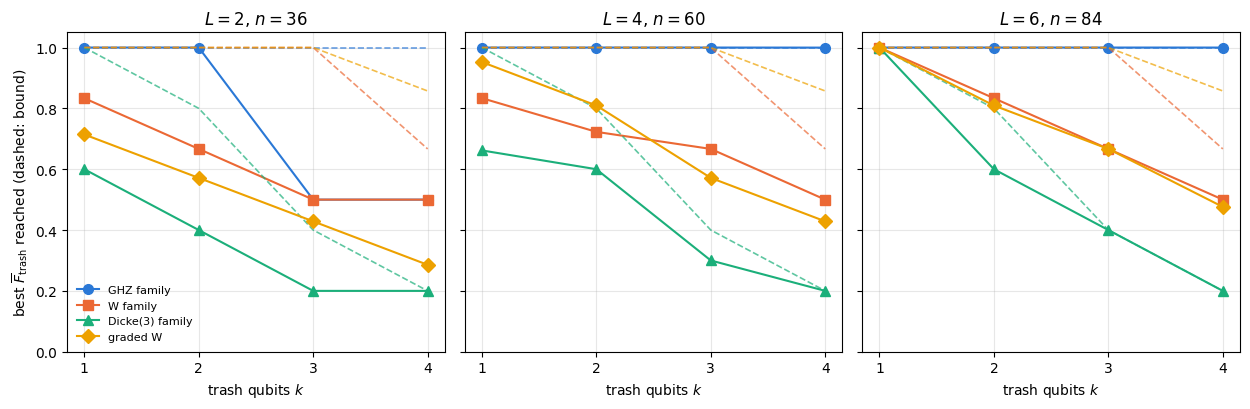

In [10]:
# ==============================================================================
# STEP 7: what was reached, against the bound of Eq. (13)
# ==============================================================================
print(f"best average trash fidelity over {R_RUNS} random starts (bound of Eq. (13) in brackets)")
header = "  ".join(f"{('k=' + str(k)):>16s}" for k in range(1, K_MAX + 1))
for layers in LAYERS_SWEEP:
    print(f"\n--- L = {layers} layers, n = {hea_num_params(N_Q, layers)} angles ---")
    print(f"{'family':>16s}  {header}")
    for i, name in enumerate(FAMILIES):
        cells = []
        for k in range(1, K_MAX + 1):
            best = 1.0 - HIST[layers][i, k - 1, :, -1].min()
            cells.append(f"{best:7.4f} [{BOUND[name][k - 1]:6.4f}]")
        print(f"{name:>16s}  " + "  ".join(f"{c:>16s}" for c in cells))

fig, axes = plt.subplots(1, len(LAYERS_SWEEP), figsize=(4.2 * len(LAYERS_SWEEP), 4.2), sharey=True)
ks = np.arange(1, K_MAX + 1)
for ax, layers in zip(axes, LAYERS_SWEEP):
    for i, name in enumerate(FAMILIES):
        best = np.array([1.0 - HIST[layers][i, k - 1, :, -1].min() for k in ks])
        ax.plot(ks, best, MARKERS[i] + "-", ms=7, color=PALETTE[i], label=name if layers == LAYERS_SWEEP[0] else None)
        ax.plot(ks, BOUND[name], "--", lw=1.2, color=PALETTE[i], alpha=0.7)
    ax.set_xlabel("trash qubits $k$"); ax.set_xticks(ks)
    ax.set_title(f"$L={layers}$, $n={hea_num_params(N_Q, layers)}$")
axes[0].set_ylabel(r"best $\overline{F}_{\mathrm{trash}}$ reached (dashed: bound)")
axes[0].set_ylim(0.0, 1.05); axes[0].legend(fontsize=8, loc="lower left")
fig.tight_layout(); plt.show()

The measured table says two different things in its two halves, and the difference is the subject of Section 8.

**The GHZ family behaves exactly as the bound says it should, once the circuit is deep enough.** Its bound is $1$ at
every compression ratio. At $L=2$ the training reaches $1$ for $k=1,2$ and then stalls at *exactly* $0.5$ for $k=3$
and $k=4$. That value is not an accident: $0.5$ is what an encoder scores when it sends one of the two eigenvectors
of $\bar\rho$ into the trash-zero subspace and misses the other, and the two carry weight $1/2$ each. By $L=4$ the
bound is reached at every $k$, to four decimals.

**The higher-rank families do not reach their bounds at any depth tried.** The W family at $k=2$ climbs $0.667$,
$0.723$, $0.833$ as layers are added, against a bound of $1$; the Dicke($3$) family at $k=2$ reaches $0.400$, $0.600$,
$0.600$ against a bound of $0.800$; the graded W family at $k=2$ reaches $0.571$, $0.810$, $0.810$ against $1$.

The plateau values are again conspicuously rational — $5/6$, $4/6$, $12/20$, $17/21$ — which is the same signature as
the GHZ case: a fixed number of the eigenvectors of $\bar\rho$ is routed and the rest are missed. **Whether that is
the fault of the circuit or of the optimiser is a question that has to be answered by measurement, not by
assertion**, and Section 8 answers it.

## 8. The gap: ansatz or optimiser

A trained value below a bound admits exactly two explanations, and they call for opposite responses.

* **Optimisation failure**: the circuit *can* reach the bound, but the landscape has minima that the optimiser falls
  into. Symptoms: the result improves with more iterations, with a different step size, or with more random restarts,
  and the successful runs are a minority.
* **Expressivity limit**: no choice of angles reaches the bound. Symptoms: every random start converges to the *same*
  value, and that value does not move when the optimiser is given more resources.

The two diagnostics below apply this test to the W family at $k=2$, whose bound is $1$ and whose best reached value
at $L=6$ was $0.8333=5/6$.

1. **Resource insensitivity.** Run the same problem at two step sizes and two iteration budgets differing by a factor
   of five.
2. **Depth.** Add layers well beyond the sweep of Section 7 and see whether the plateau lifts.

In [11]:
# ==============================================================================
# STEP 8: diagnosis 1 -- does the plateau move when the optimiser is given more?
# ==============================================================================
NAME_D, K_D = "W family", 2
lams_D, vecs_D = SPECTRA[NAME_D]
i_D = list(FAMILIES).index(NAME_D)


def train_diag(layers, lr, n_steps, n_runs=8, seed=7):
    """Best and median trash fidelity reached at this depth with these optimiser settings."""
    theta0, keys = random_starts(n_runs, hea_num_params(N_Q, layers), seed)
    cost = lambda th: 1.0 - avg_trash_fidelity(th, lams_D, vecs_D, K_D - 1, N_Q, layers)
    _, h = jax.jit(jax.vmap(lambda t, kk: train(t, kk, lambda th, k2, i: jax.grad(cost)(th),
                                                opt_adam(lr), cost, n_steps)))(theta0, keys)
    return 1.0 - np.asarray(jax.block_until_ready(h))[:, -1]


print(f"{NAME_D}, k = {K_D}, L = 6: bound {BOUND[NAME_D][K_D - 1]:.4f}; 8 random starts each")
print(f"{'learning rate':>14s} {'iterations':>11s} {'best':>9s} {'median':>9s} {'worst':>9s}")
for lr in (0.02, 0.10):
    for ns in (120, 600):
        F = train_diag(6, lr, ns)
        print(f"{lr:14.2f} {ns:11d} {F.max():9.5f} {np.median(F):9.5f} {F.min():9.5f}")

W family, k = 2, L = 6: bound 1.0000; 8 random starts each
 learning rate  iterations      best    median     worst


          0.02         120   0.83320   0.72479   0.66657


          0.02         600   0.83333   0.83333   0.66667


          0.10         120   0.83333   0.66667   0.66666


          0.10         600   0.83333   0.66667   0.66667


W family, k = 2: reachability against depth (47.6 s)
  L     n      best    median     worst   starts above 0.99
  2    36   0.66667   0.66667   0.66667            0 / 8
  4    60   0.83074   0.66667   0.66666            0 / 8
  6    84   0.83334   0.83333   0.66666            0 / 8
  9   120   1.00000   0.83333   0.83329            1 / 8
 12   156   0.99975   0.83332   0.83250            1 / 8


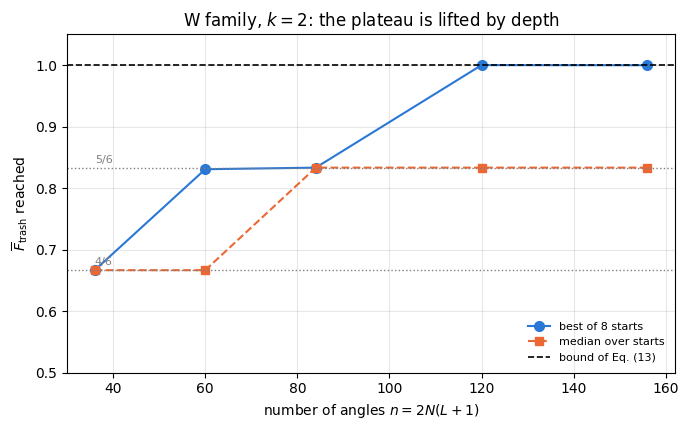

In [12]:
# ==============================================================================
# STEP 9: diagnosis 2 -- the plateau against circuit depth
# ==============================================================================
DEPTHS_DIAG = (2, 4, 6, 9, 12)
R_DIAG, N_STEPS_DIAG = 8, 300
diag = {}
t0 = time.perf_counter()
for layers in DEPTHS_DIAG:
    diag[layers] = train_diag(layers, LR, N_STEPS_DIAG, n_runs=R_DIAG, seed=7)
print(f"{NAME_D}, k = {K_D}: reachability against depth ({time.perf_counter() - t0:.1f} s)")
print(f"{'L':>3s} {'n':>5s} {'best':>9s} {'median':>9s} {'worst':>9s} {'starts above 0.99':>19s}")
for layers in DEPTHS_DIAG:
    F = diag[layers]
    print(f"{layers:3d} {hea_num_params(N_Q, layers):5d} {F.max():9.5f} {np.median(F):9.5f} {F.min():9.5f} "
          f"{int(np.sum(F > 0.99)):12d} / {R_DIAG:d}")

fig, ax = plt.subplots(figsize=(7.0, 4.4))
ns_axis = [hea_num_params(N_Q, L) for L in DEPTHS_DIAG]
ax.plot(ns_axis, [diag[L].max() for L in DEPTHS_DIAG], MARKERS[0] + "-", ms=7, color=PALETTE[0],
        label=f"best of {R_DIAG} starts")
ax.plot(ns_axis, [np.median(diag[L]) for L in DEPTHS_DIAG], MARKERS[1] + "--", ms=6, color=PALETTE[1],
        label="median over starts")
ax.axhline(BOUND[NAME_D][K_D - 1], color="k", ls="--", lw=1.2, label="bound of Eq. (13)")
for frac, lab in ((4 / 6, "4/6"), (5 / 6, "5/6")):
    ax.axhline(frac, color="grey", ls=":", lw=1.0)
    ax.text(ns_axis[0], frac + 0.008, lab, fontsize=8, color="grey")
ax.set_xlabel("number of angles $n=2N(L+1)$"); ax.set_ylabel(r"$\overline{F}_{\mathrm{trash}}$ reached")
ax.set_ylim(0.5, 1.05)
ax.set_title(f"{NAME_D}, $k={K_D}$: the plateau is lifted by depth")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout(); plt.show()

**Diagnosis 1: extra optimiser resources buy nothing above $5/6$.** Across a factor of five in the iteration budget
and a factor of five in the step size, the best of eight random starts is $0.8332$, $0.83333$, $0.83333$, $0.83333$ —
the same value to four decimals in all four settings. The *median* does move, from $0.667$ to $0.833$ and back, which
is the ordinary sensitivity of which local minimum a run falls into; what never moves is the ceiling. A value that
more iterations and a larger step size cannot exceed is not a value the optimiser is merely failing to find.

**Diagnosis 2: depth lifts the ceiling.** The plateau is not a property of the task — the bound is $1$ and Section 6
proved it is attainable by *some* unitary. It is a property of the $L$-layer hardware-efficient ansatz. The ceiling
rises in steps of one eigenvector as layers are added: $4/6$ at $L=2$, $5/6$ at $L=4$ and $L=6$, and at $L=9$ a run
reaches $1.00000$ for the first time. The success rate stays low — one start in eight at $L=9$ and at $L=12$ — so
the deep circuit has an expressivity problem *and* a trainability problem, and only the first of the two is cured by
depth.

The depth required is much larger than a parameter count would suggest, and there is a counting argument for why.
Requiring $U$ to map an $r$-dimensional subspace into an $m$-dimensional one is $2r(d-m)$ real conditions on $U$,
with $d=2^N$. For the W family at $k=2$ that is $2\cdot6\cdot(64-16)=576$ conditions, while $L=6$ supplies only
$n=84$ angles. The solution set has codimension $576$ in the unitary group and a generic $84$-dimensional family
misses it — whereas the GHZ family, with $r=2$ and $m=32$, needs only $2\cdot2\cdot32=128$ conditions and is found
easily. The counting is not a theorem (the ansatz is not in generic position, and the single-state results of
Section 9 beat it), but it gets the ordering of difficulty right.

> **Numerical practice.** "The optimiser got stuck" and "the ansatz cannot do it" produce the same number and require
> different fixes — more restarts against more layers. The two diagnostics above cost one extra sweep each and settle
> the question. Never report the first explanation without running the second.

## 9. The Schmidt-rank narrative, re-examined

A common way to talk about quantum compression runs: *a GHZ state has Schmidt rank $2$ across any cut, a W state also
has Schmidt rank $2$, so both compress well; a Dicke state has a much larger Schmidt rank, so it is hard.* Section 6
suggests this is the right ordering for the wrong reason, so we check both statements numerically: the Schmidt ranks
themselves, and what compression of the **single** states actually achieves.

single states of N = 6 qubits, bipartition (first 3 | last 3)
           state  Schmidt rank   entropy S_A [bits]   rank of rho_avg  bound at k=4


       GHZ state             2               1.0000                 1        1.0000
         W state             2               1.0000                 1        1.0000
  Dicke(3) state             4               1.4690                 1        1.0000



compressing a SINGLE state (bound = 1.0000 for every k, since rank(rho_avg) = 1)
           state   L                k=1                 k=2                 k=3                 k=4
       GHZ state   2    1.0000 / 1.0000     1.0000 / 1.0000     0.5000 / 0.5000     0.5000 / 0.5000
                   4    1.0000 / 1.0000     1.0000 / 1.0000     1.0000 / 1.0000     1.0000 / 1.0000
                   6    1.0000 / 1.0000     1.0000 / 1.0000     1.0000 / 1.0000     1.0000 / 1.0000
         W state   2    0.9363 / 0.9363     0.8477 / 0.8477     0.7024 / 0.7024     0.6667 / 0.6314
                   4    1.0000 / 1.0000     1.0000 / 1.0000     1.0000 / 0.9946     1.0000 / 0.9935
                   6    1.0000 / 1.0000     1.0000 / 1.0000     1.0000 / 1.0000     1.0000 / 1.0000
  Dicke(3) state   2    0.8162 / 0.8162     0.7664 / 0.7664     0.4618 / 0.4599     0.4563 / 0.4399
                   4    0.9864 / 0.9815     0.9769 / 0.9692     0.9672 / 0.9596     0.9615 / 0.9407
                  

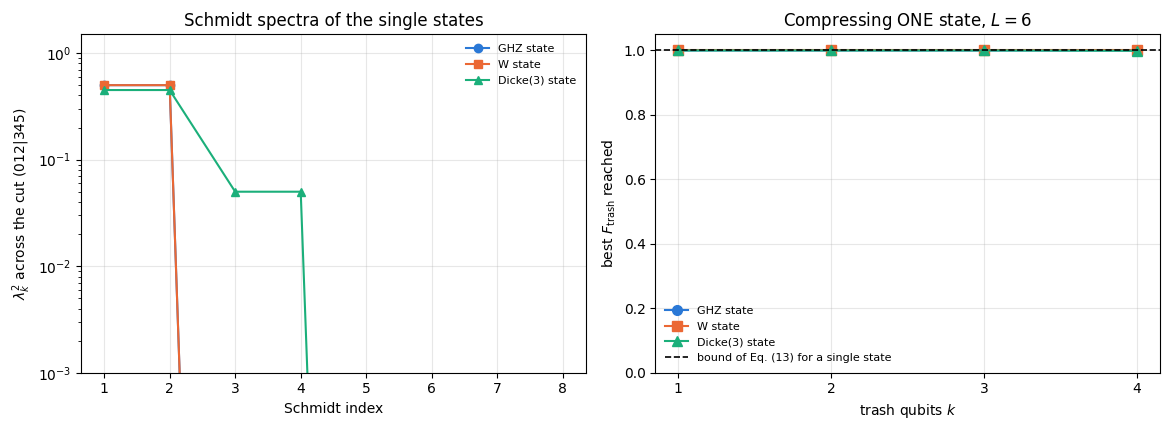

In [13]:
# ==============================================================================
# STEP 10: Schmidt spectra of the single states, and what Eq. (13) says about them
# ==============================================================================
SINGLES = {"GHZ state": ghz_state(N_Q), "W state": w_state(N_Q), "Dicke(3) state": dicke_state(N_Q, 3)}
print(f"single states of N = {N_Q} qubits, bipartition (first 3 | last 3)")
print(f"{'state':>16s} {'Schmidt rank':>13s} {'entropy S_A [bits]':>20s} {'rank of rho_avg':>17s} "
      f"{'bound at k=4':>13s}")
for name, psi in SINGLES.items():
    sv = np.asarray(schmidt_values(psi, (0, 1, 2)))
    rank = int(np.sum(sv > 1e-10))
    S = float(entanglement_entropy(psi, (0, 1, 2)))
    print(f"{name:>16s} {rank:13d} {S:20.4f} {1:17d} {1.0:13.4f}")

# Train the encoder on each SINGLE state.  rank(rho_avg) = 1, so r_max = 1 suffices and the sweep is 20 times
# cheaper than the ensemble sweep of Step 6.
SINGLE_SPECTRA = jnp.stack([ensemble_spectrum(psi[None, ...], r_max=1)[0] for psi in SINGLES.values()])
SINGLE_VECS = jnp.stack([ensemble_spectrum(psi[None, ...], r_max=1)[1] for psi in SINGLES.values()])


def sweep_singles(layers, n_steps=300, seed=9):
    theta0, keys = random_starts(R_RUNS, hea_num_params(N_Q, layers), seed)

    def one(lams, vecs, k_idx, t0, key):
        cost = lambda th: 1.0 - avg_trash_fidelity(th, lams, vecs, k_idx, N_Q, layers)
        return train(t0, key, lambda th, kk, i: jax.grad(cost)(th), opt_adam(LR), cost, n_steps)[1]

    per_k = lambda lams, vecs: jax.vmap(
        lambda k_idx: jax.vmap(lambda t, kk: one(lams, vecs, k_idx, t, kk))(theta0, keys))(K_INDEX)
    return jax.jit(jax.vmap(per_k))(SINGLE_SPECTRA, SINGLE_VECS)


HIST_S = {L: np.asarray(jax.block_until_ready(sweep_singles(L))) for L in LAYERS_SWEEP}
print(f"\ncompressing a SINGLE state (bound = 1.0000 for every k, since rank(rho_avg) = 1)")
print(f"{'state':>16s} {'L':>3s} " + "  ".join(f"{('k=' + str(k)):>18s}" for k in range(1, K_MAX + 1)))
for i, name in enumerate(SINGLES):
    for layers in LAYERS_SWEEP:
        cells = []
        for k in range(1, K_MAX + 1):
            F_end = 1.0 - HIST_S[layers][i, k - 1, :, -1]
            cells.append(f"{F_end.max():.4f} / {np.median(F_end):.4f}")
        print(f"{name if layers == LAYERS_SWEEP[0] else '':>16s} {layers:3d} " +
              "  ".join(f"{c:>18s}" for c in cells))
print("   (entries are  best / median  over the random starts)")

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4))
for i, (name, psi) in enumerate(SINGLES.items()):
    sv = np.sort(np.asarray(schmidt_values(psi, (0, 1, 2))) ** 2)[::-1]
    axes[0].semilogy(np.arange(1, sv.size + 1), np.maximum(sv, 1e-18), MARKERS[i] + "-", ms=6,
                     color=PALETTE[i], label=name)
axes[0].set_ylim(1e-3, 1.5)
axes[0].set_xlabel("Schmidt index"); axes[0].set_ylabel(r"$\lambda_k^2$ across the cut $(012\vert345)$")
axes[0].set_title("Schmidt spectra of the single states"); axes[0].legend(fontsize=8)

for i, name in enumerate(SINGLES):
    best = np.array([1.0 - HIST_S[LAYERS_SWEEP[-1]][i, k - 1, :, -1].min() for k in ks])
    axes[1].plot(ks, best, MARKERS[i] + "-", ms=7, color=PALETTE[i], label=name)
axes[1].axhline(1.0, color="k", ls="--", lw=1.2, label="bound of Eq. (13) for a single state")
axes[1].set_ylim(0.0, 1.05); axes[1].set_xticks(ks)
axes[1].set_xlabel("trash qubits $k$"); axes[1].set_ylabel(r"best $F_{\mathrm{trash}}$ reached")
axes[1].set_title(f"Compressing ONE state, $L={LAYERS_SWEEP[-1]}$"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

The Schmidt ranks come out as the folklore says, and the entropies order the same way: the GHZ and W states both have
rank $2$ across the balanced cut — a GHZ state because it has two terms, a W state because the excitation is either
in $A$ or in $B$, giving $\vert u\rangle_A\vert000\rangle_B+\vert000\rangle_A\vert v\rangle_B$ — while the Dicke state
with three excitations must distribute them as $3+0$, $2+1$, $1+2$ or $0+3$ and therefore has rank $4$.

**That ordering does not predict compressibility of the single states, because all three are perfectly compressible.**
Their averaged density matrix has rank $1$, so Eq. (13) gives a bound of $1$ for every $k$, and the training finds it:
at $L=6$ every one of the three states reaches a trash fidelity indistinguishable from $1$ at every compression ratio
studied. A Dicke state is exactly as compressible as a GHZ state, because compressing one state means rotating one
vector onto one vector.

What the Schmidt rank does control is a different question — how many parameters a *product-form* or matrix-product
representation of that single state needs, and how hard it is for a *shallow, local* circuit to perform the required
rotation. Both are visible in the table as the number of layers needed, not as the fidelity reached.

The folklore ordering GHZ $<$ W $<$ Dicke is therefore correct, but it belongs to Section 6: it is a statement about
the **families**, whose averaged states have rank $2$, $6$ and $20$. Once the question is asked about an ensemble, the
right invariant appears, it is the spectrum of $\bar\rho$, and it reproduces the ordering with exact numbers instead
of an intuition.

> **Common pitfall.** "This state is highly entangled, so it is hard to compress" confuses two different resources.
> Entanglement is a property of one state across one cut; compressibility is a property of an ensemble, and it is
> measured by how many dimensions that ensemble occupies. The GHZ family is maximally entangled and maximally
> compressible at the same time.

## 10. Training on trajectory estimates

Everything above used the exact cost and its exact gradient, which no device can supply. The device-realistic version
replaces Eq. (16) by its measured estimate: run the circuit $M$ times on each ensemble member, measure the trash
qubits, and count how often they all come out zero. The cost is then a binomial proportion with standard error
$\sqrt{F(1-F)/M}$ per member, and the gradient must come from SPSA (notebook 41), which needs two cost evaluations
per iteration regardless of the number of angles.

The comparison below runs the same problem three ways from the same initialisations: exact gradients, SPSA on the
exact cost (isolating the price of the gradient rule), and SPSA on the trajectory estimate (adding the price of
finite statistics). The monitored quantity is always the **exact** trash fidelity, because we want to know how good
the encoder really is, not what its noisy estimate claimed.

exact gradient                        4.3 s   exact F_trash reached: best 1.00000, median 1.00000


SPSA, exact cost                      2.8 s   exact F_trash reached: best 0.97368, median 0.63687


SPSA, M=64 trajectories/member        5.1 s   exact F_trash reached: best 0.47493, median 0.44916

bound of Eq. (13) for GHZ family at k = 3: 1.00000
shot-noise scale of the stochastic cost: 1/sqrt(M * n_members) = 0.0884


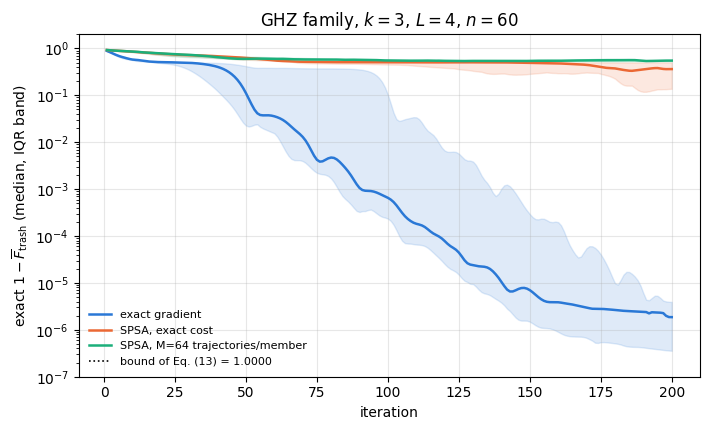

In [14]:
# ==============================================================================
# STEP 11: exact gradients vs SPSA vs SPSA on measure-and-reset trajectories
# ==============================================================================
# PARAMETERS -- the GHZ family at L = 4, where Section 7 measured that the ansatz DOES reach the bound of 1,
# so that any shortfall below is attributable to the gradient rule and to the statistics, not to the circuit.
NAME_T, K_T, L_T = "GHZ family", 3, 4
M_SHOT = 64                       # trajectories per ensemble member per cost evaluation
R_T, N_STEPS_T = 6, 200
C_SPSA, GAMMA_SPSA = 0.2, 0.101

ens_T = FAMILIES[NAME_T]
lams_T, vecs_T = SPECTRA[NAME_T]
n_par_T = hea_num_params(N_Q, L_T)
cost_exact_T = jax.jit(lambda th: 1.0 - avg_trash_fidelity(th, lams_T, vecs_T, K_T - 1, N_Q, L_T))


def cost_trajectory(key, theta, M=M_SHOT):
    """Shot-based estimate of 1 - F_trash: measure the trash of M runs of every ensemble member and count.

    The estimator is the fraction of runs in which ALL k trash qubits returned 0 -- exactly the quantity a
    device reads off.  Unbiased, with a binomial standard error sqrt(F(1-F)/(M * n_members)).
    """
    keys = jax.random.split(key, ens_T.shape[0] * M).reshape(ens_T.shape[0], M, 2)

    def one_member(psi, ks):
        outs = jax.vmap(lambda kk: autoencoder_trajectory(kk, theta, psi, N_Q, L_T, K_T)[0])(ks)
        return jnp.mean(jnp.all(outs == 0, axis=1))

    return 1.0 - jnp.mean(jax.vmap(one_member)(ens_T, keys))


def grad_spsa(cost_fn, stochastic, c=C_SPSA, gamma=GAMMA_SPSA):
    """SPSA gradient rule (notebook 41, Eq. 12); `stochastic` says whether the cost consumes a PRNG key."""
    def rule(theta, key, k):
        c_k = c / k ** gamma
        kd, kp, km = jax.random.split(key, 3)
        delta = jax.random.rademacher(kd, theta.shape).astype(theta.dtype)
        if stochastic:
            up, dn = cost_fn(kp, theta + c_k * delta), cost_fn(km, theta - c_k * delta)
        else:
            up, dn = cost_fn(theta + c_k * delta), cost_fn(theta - c_k * delta)
        return (up - dn) / (2 * c_k) * delta
    return rule


th_T, ks_T = random_starts(R_T, n_par_T, seed=31)
RULES = (("exact gradient", lambda th, kk, i: jax.grad(cost_exact_T)(th)),
         ("SPSA, exact cost", grad_spsa(cost_exact_T, False)),
         (f"SPSA, M={M_SHOT} trajectories/member", grad_spsa(cost_trajectory, True)))
hist_T = {}
for name, rule in RULES:
    t0 = time.perf_counter()
    _, h = jax.jit(jax.vmap(lambda t, kk: train(t, kk, rule, opt_adam(LR), cost_exact_T, N_STEPS_T)))(th_T, ks_T)
    hist_T[name] = np.asarray(jax.block_until_ready(h))
    F_end = 1.0 - hist_T[name][:, -1]
    print(f"{name:34s} {time.perf_counter() - t0:6.1f} s   exact F_trash reached: "
          f"best {F_end.max():.5f}, median {np.median(F_end):.5f}")
print(f"\nbound of Eq. (13) for {NAME_T} at k = {K_T}: {BOUND[NAME_T][K_T - 1]:.5f}")
print(f"shot-noise scale of the stochastic cost: 1/sqrt(M * n_members) = "
      f"{1 / np.sqrt(M_SHOT * ens_T.shape[0]):.4f}")

fig, ax = plt.subplots(figsize=(7.2, 4.4))
it_T = np.arange(1, N_STEPS_T + 1)
for j, (name, _) in enumerate(RULES):
    lo, med, hi = bands(np.maximum(hist_T[name], 1e-12))
    ax.fill_between(it_T, lo, hi, color=PALETTE[j], alpha=0.15)
    ax.semilogy(it_T, med, "-", lw=1.8, color=PALETTE[j], label=name)
ax.axhline(max(1.0 - BOUND[NAME_T][K_T - 1], 1e-12), color="k", ls=":", lw=1.2,
           label=f"bound of Eq. (13) = {BOUND[NAME_T][K_T - 1]:.4f}")
ax.set_ylim(1e-7, 2.0)
ax.set_xlabel("iteration"); ax.set_ylabel(r"exact $1-\overline{F}_{\mathrm{trash}}$ (median, IQR band)")
ax.set_title(f"{NAME_T}, $k={K_T}$, $L={L_T}$, $n={n_par_T}$")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

Each step down the list costs accuracy, and the two costs are of different kinds.

**The exact gradient solves the problem**: every one of the six starts reaches $\overline F_{\rm trash}=1.00000$, the
bound. That is the reference the other two rows are measured against, and it is what makes this configuration the
right test bed.

**SPSA on the exact cost costs information**: one scalar per iteration instead of $n=60$, so progress is far slower
and far more start-dependent — the best run reaches $0.974$ and the median only $0.637$ in the same 200 iterations.
This is the behaviour measured in notebook 41, reproduced on a different cost.

**SPSA on the trajectory estimate costs resolution as well**, and here it is decisive: the best run reaches $0.475$
and the median $0.449$, barely above where it started. With $M=64$ runs on each of the two ensemble members the
standard error of one cost evaluation is $1/\sqrt{128}\approx0.088$, and the SPSA difference quotient subtracts two
such numbers and divides by $2c_k\approx0.3$: the noise in the gradient estimate is of order $0.4$ per component,
comparable to the gradient itself. The optimiser is following sampling noise, and a shot budget of $128$ per cost
evaluation is simply not enough for this landscape.

> **Numerical practice.** The floor of a shot-limited optimisation is set by the estimator, not by the optimiser.
> Raising $M$ lowers the floor as $1/\sqrt M$ and raises the cost linearly, which is why real implementations
> increase the shot budget as the run converges rather than paying for precision from the first iteration.

## 11. Generalisation

An autoencoder is useful only if it compresses states it was **not** trained on. Section 6 makes the prediction sharp:
training on a subset $S$ optimises $\mathrm{Tr}(\bar\rho_S\,U^\dagger\Pi U)$, and an encoder optimal for
$\bar\rho_S$ is optimal for the full ensemble only if the two averaged states have the same dominant eigenspace.
**The number of members that must be seen is therefore the rank of $\bar\rho$, not the size of the family.**

The test uses a family whose bound Section 7 measured to be reachable, so that the result is about generalisation and
not about the ansatz: the one-parameter GHZ family

$$\vert\psi(\alpha)\rangle=\cos\alpha\,\vert0\cdots0\rangle+\sin\alpha\,\vert1\cdots1\rangle,
  \qquad \alpha_m=\frac{\pi m}{M},\quad m=0,\dots,M-1,\tag{18}$$

with $M=8$ members. Averaging over the grid kills the cross terms
($\sum_m\cos\alpha_m\sin\alpha_m=\tfrac12\sum_m\sin(2\pi m/M)=0$) and gives
$\bar\rho=\tfrac12\vert0\cdots0\rangle\langle0\cdots0\vert+\tfrac12\vert1\cdots1\rangle\langle1\cdots1\vert$, of
rank $2$: eight distinct states spanning only two dimensions. Training uses the first $r$ of them, $r=1,\dots,8$,
and the encoder is then tested on all eight.

family of Eq. (18), M = 8 members: eigenvalues of rho_avg = [0.5 0.5], bound at k = 4: 1.0000


GHZ angle family, M=8, k = 4, L = 6: train on the first r members, test on all 8
  r  rank of rho_S  bound on rho_S  F on the training set   F on all members  bound on all
  1              1          1.0000                 1.0000             0.5000        1.0000
  2              2          1.0000                 1.0000             1.0000        1.0000
  3              2          1.0000                 1.0000             1.0000        1.0000
  4              2          1.0000                 1.0000             1.0000        1.0000
  5              2          1.0000                 1.0000             1.0000        1.0000
  6              2          1.0000                 1.0000             1.0000        1.0000
  7              2          1.0000                 1.0000             1.0000        1.0000
  8              2          1.0000                 1.0000             1.0000        1.0000


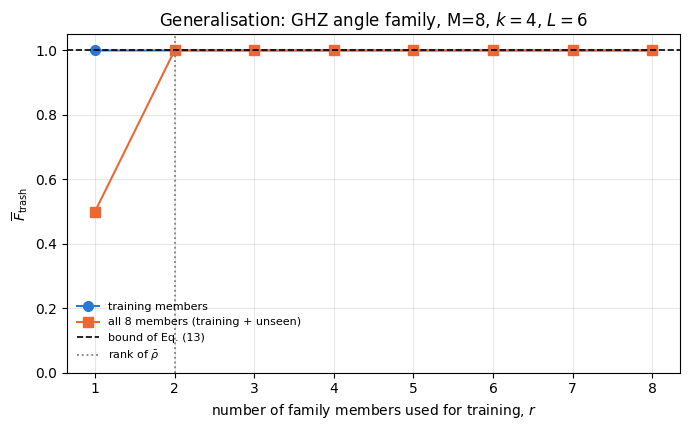

In [15]:
# ==============================================================================
# STEP 12: train on r members of the family, test on all of them
# ==============================================================================
K_G, L_G, M_FAM = 4, 6, 8
NAME_G = f"GHZ angle family, M={M_FAM}"
_v = np.zeros((M_FAM, 2 ** N_Q), dtype=complex)
for _m in range(M_FAM):
    _a = np.pi * _m / M_FAM
    _v[_m, 0], _v[_m, -1] = np.cos(_a), np.sin(_a)
ens_G = jnp.asarray(_v.reshape((M_FAM,) + (2,) * N_Q), dtype=CDTYPE)
n_mem = M_FAM
lam_G_full = np.asarray(ensemble_spectrum(ens_G, r_max=2)[0])
BOUND_G = float(np.sum(np.sort(lam_G_full)[::-1][:2 ** (N_Q - K_G)]))
print(f"family of Eq. (18), M = {M_FAM} members: eigenvalues of rho_avg = {np.round(lam_G_full, 6)}, "
      f"bound at k = {K_G}: {BOUND_G:.4f}")

sub_spectra = [ensemble_spectrum(ens_G[:r], r_max=2) for r in range(1, n_mem + 1)]
LAMS_G = jnp.stack([s[0] for s in sub_spectra])
VECS_G = jnp.stack([s[1] for s in sub_spectra])
R_GEN, N_STEPS_GEN = 8, 250
theta0_G, keys_G = random_starts(R_GEN, hea_num_params(N_Q, L_G), seed=71)


def train_subset(lams, vecs):
    """Train on the ensemble described by (lams, vecs); return the final theta of every random start."""
    cost = lambda th: 1.0 - avg_trash_fidelity(th, lams, vecs, K_G - 1, N_Q, L_G)
    return jax.vmap(lambda t, kk: train(t, kk, lambda th, k2, i: jax.grad(cost)(th),
                                        opt_adam(LR), cost, N_STEPS_GEN)[0])(theta0_G, keys_G)


THETA_G = jax.block_until_ready(jax.jit(jax.vmap(train_subset))(LAMS_G, VECS_G))   # (n_mem, R_GEN, n_par)
train_F = np.zeros((n_mem, R_GEN))
test_F = np.zeros((n_mem, R_GEN))
per_member = jax.jit(jax.vmap(lambda th: jax.vmap(
    lambda psi: trash_fidelities(encode(th, psi, N_Q, L_G))[K_G - 1])(ens_G)))
for r in range(1, n_mem + 1):
    F_all = np.asarray(per_member(THETA_G[r - 1]))                 # (R_RUNS, n_mem)
    train_F[r - 1] = F_all[:, :r].mean(axis=1)
    test_F[r - 1] = F_all.mean(axis=1)

print(f"{NAME_G}, k = {K_G}, L = {L_G}: train on the first r members, test on all {n_mem}")
print(f"{'r':>3s} {'rank of rho_S':>14s} {'bound on rho_S':>15s} {'F on the training set':>22s} "
      f"{'F on all members':>18s} {'bound on all':>13s}")
for r in range(1, n_mem + 1):
    lam_S = np.asarray(sub_spectra[r - 1][0])
    bound_S = float(np.sum(np.sort(lam_S)[::-1][:2 ** (N_Q - K_G)]))
    j = int(np.argmax(train_F[r - 1]))                              # the run that did best on its training set
    print(f"{r:3d} {int(np.sum(lam_S > 1e-10)):14d} {bound_S:15.4f} {train_F[r - 1, j]:22.4f} "
          f"{test_F[r - 1, j]:18.4f} {BOUND_G:13.4f}")

fig, ax = plt.subplots(figsize=(7.0, 4.4))
rs = np.arange(1, n_mem + 1)
best_j = [int(np.argmax(train_F[r - 1])) for r in rs]
ax.plot(rs, [train_F[r - 1, best_j[r - 1]] for r in rs], MARKERS[0] + "-", ms=7, color=PALETTE[0],
        label="training members")
ax.plot(rs, [test_F[r - 1, best_j[r - 1]] for r in rs], MARKERS[1] + "-", ms=7, color=PALETTE[1],
        label="all 8 members (training + unseen)")
ax.axhline(BOUND_G, color="k", ls="--", lw=1.2, label="bound of Eq. (13)")
ax.axvline(2, color="grey", ls=":", lw=1.3, label=r"rank of $\bar{\rho}$")
ax.set_xlabel("number of family members used for training, $r$")
ax.set_ylabel(r"$\overline{F}_{\mathrm{trash}}$")
ax.set_title(f"Generalisation: {NAME_G}, $k={K_G}$, $L={L_G}$")
ax.set_ylim(0.0, 1.05); ax.legend(fontsize=8, loc="lower left")
fig.tight_layout(); plt.show()

The transition is as sharp as the theory demands, and it happens at $r=2$, not at $r=8$.

**$r=1$: textbook overfitting.** Trained on the single state $\vert0\cdots0\rangle$, the encoder reaches a trash
fidelity of exactly $1$ on that state — and exactly $0.5000$ averaged over the eight. The number is not
approximate: $\bar\rho$ of the full family puts weight $\tfrac12$ on $\vert0\cdots0\rangle$ and $\tfrac12$ on
$\vert1\cdots1\rangle$, and the encoder learned the first and ignored the second. Perfect on what it saw, worth half
on what it did not.

**$r\ge2$: perfect generalisation, immediately.** Two members already span the support of $\bar\rho$, so the encoder
trained on them is optimal for all eight — measured trash fidelity $1.0000$ on the training set and $1.0000$ on the
full family, unchanged as $r$ grows to $8$. Showing the autoencoder six more states taught it nothing, because there
was nothing left to learn.

> **Physics insight.** A quantum autoencoder does not learn states; it learns a *subspace*. Any training set whose
> averaged density matrix has the same dominant eigenspace as the full ensemble produces the same encoder. The size
> of the training set is the wrong quantity to report; the rank it spans is the right one.

## 12. Gate noise in the encoder

On hardware the encoder is not a unitary but the noisy channel of notebook 44: a depolarising channel of strength
$p_1$ after every rotation pair and of strength $p_2$ on both qubits of every $CZ$. Two effects are expected and have
opposite signs, so the measurement decides which wins.

* Noise mixes population into trash states other than $\vert0\cdots0\rangle$, which lowers $F_{\rm trash}$ — even for
  a perfect encoder.
* A depolarised state is closer to the maximally mixed state, whose trash fidelity is $2^{-k}$, so there is a floor
  rather than a collapse to zero.

The study drops to $N=4$ so the density tensor stays at $4^4=256$ numbers and `jax.grad` runs through the Kraus
einsums cheaply. The ensemble is the four-qubit GHZ family, of rank $2$, compressed to $k=2$ trash qubits: Section 7
established that this is a configuration whose noiseless bound of $1$ the ansatz reaches from every random start, so
everything the curves show below is the noise.

p = 0 checkpoint: density tensor 0.192908703848  pure state 0.192908703848


trained at 5 noise levels x 6 starts in 8.9 s

N = 4 GHZ family, k = 2, L = 3; noiseless bound 1.0000, maximally mixed floor 2^-k = 0.2500
     p2  best F_trash    median  1 - F (best)
  0.000       1.00000   1.00000       0.00000
  0.005       0.95700   0.94812       0.04300
  0.020       0.84546   0.82274       0.15454
  0.050       0.67263   0.65552       0.32737
  0.100       0.49119   0.47700       0.50881


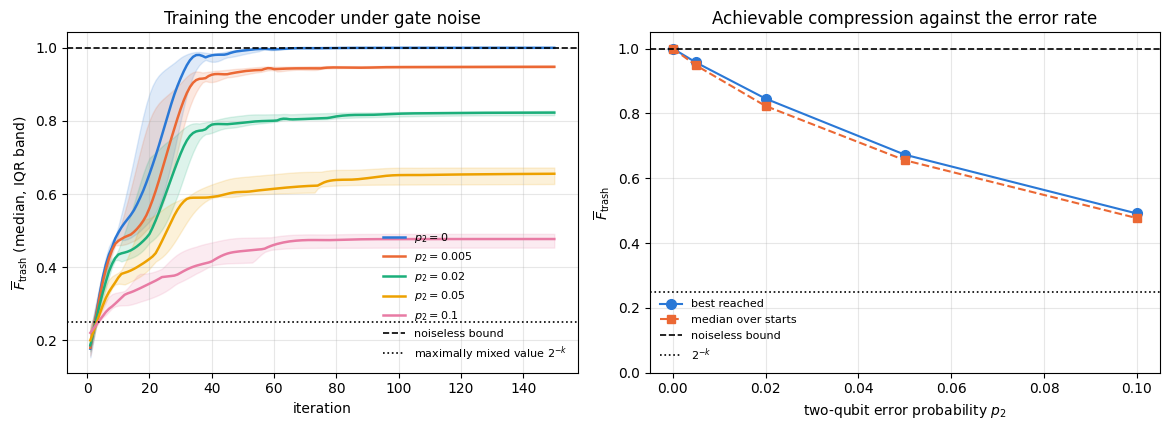

In [16]:
# ==============================================================================
# STEP 13: the autoencoder with a depolarising channel after every gate
# ==============================================================================
# PARAMETERS
N_N, L_N, K_N = 4, 3, 2
P1_RATIO = 0.1
P_LIST = jnp.asarray([0.0, 0.005, 0.02, 0.05, 0.10])
R_N, N_STEPS_N = 6, 150

ens_N = phase_family(N_N, [0, 2 ** N_N - 1])
lams_N, vecs_N = ensemble_spectrum(ens_N, r_max=2)
bound_N = float(jnp.sum(jnp.sort(lams_N)[::-1][:2 ** (N_N - K_N)]))
TRASH_MASK_N = jnp.asarray(np.array([[1.0 if (j % 2 ** k == 0) else 0.0 for j in range(2 ** K_N)]
                                     for k in range(1, K_N + 1)]), dtype=RDTYPE)


def noisy_encode_dm(theta, rho, N, layers, p1, p2):
    """Encoder on a density tensor with a depolarising channel after every gate (notebook 44, Step 2)."""
    K1, K2 = kraus_depolarizing(p1), kraus_depolarizing(p2)
    th = theta.reshape(layers + 1, N, 2)

    def rot(r, row):
        for q in range(N):
            r = apply_gate_dm(r, ry(row[q, 0]), [q])
            r = apply_gate_dm(r, rz(row[q, 1]), [q])
            r = apply_kraus_dm(r, K1, [q])
        return r

    def ent(r):
        for q in range(N - 1):
            r = apply_gate_dm(r, CZ, [q, q + 1])
            r = apply_kraus_dm(r, K2, [q])
            r = apply_kraus_dm(r, K2, [q + 1])
        return r

    rho, _ = lax.scan(lambda r, row: (ent(rot(r, row)), None), rho, th[:layers])
    return rot(rho, th[layers])


def trash_fidelity_dm(rho, k):
    """<0^k| rho_T |0^k> for the LAST k qubits of a density tensor: sum_l rho[l,0...0 ; l,0...0]."""
    N = rho.ndim // 2
    m = dm_matrix(rho).reshape(2 ** (N - k), 2 ** k, 2 ** (N - k), 2 ** k)
    return jnp.real(jnp.trace(m[:, 0, :, 0]))


def avg_trash_noisy(theta, p):
    """Average trash fidelity of the N_N-qubit W family under gate noise of strength p (traced)."""
    per = jax.vmap(lambda v: trash_fidelity_dm(
        noisy_encode_dm(theta, to_dm(v), N_N, L_N, P1_RATIO * p, p), K_N))(vecs_N)
    return jnp.sum(lams_N * per)


# CHECKPOINT: at p = 0 the noisy density-tensor cost must equal the pure-state cost
th_n = jax.random.uniform(jax.random.PRNGKey(2), (hea_num_params(N_N, L_N),), minval=-jnp.pi, maxval=jnp.pi)
pure_val = float(jnp.sum(lams_N * jax.vmap(lambda v: (TRASH_MASK_N @ jnp.sum(
    jnp.abs(encode(th_n, v, N_N, L_N).reshape(-1, 2 ** K_N)) ** 2, axis=0))[K_N - 1])(vecs_N)))
print(f"p = 0 checkpoint: density tensor {float(avg_trash_noisy(th_n, 0.0)):.12f}  "
      f"pure state {pure_val:.12f}")
assert abs(float(avg_trash_noisy(th_n, 0.0)) - pure_val) < TOL

theta0_N, keys_N = random_starts(R_N, hea_num_params(N_N, L_N), seed=55)


def train_noisy(p):
    cost = lambda th: 1.0 - avg_trash_noisy(th, p)
    return jax.vmap(lambda t, kk: train(t, kk, lambda th, k2, i: jax.grad(cost)(th),
                                        opt_adam(LR), cost, N_STEPS_N)[1])(theta0_N, keys_N)


t0 = time.perf_counter()
HIST_N = np.asarray(jax.block_until_ready(jax.jit(jax.vmap(train_noisy))(P_LIST)))
print(f"trained at {P_LIST.size} noise levels x {R_N} starts in {time.perf_counter() - t0:.1f} s")

mixed_floor = 2.0 ** (-K_N)
print(f"\nN = {N_N} GHZ family, k = {K_N}, L = {L_N}; noiseless bound {bound_N:.4f}, "
      f"maximally mixed floor 2^-k = {mixed_floor:.4f}")
print(f"{'p2':>7s} {'best F_trash':>13s} {'median':>9s} {'1 - F (best)':>13s}")
for j, p in enumerate(np.asarray(P_LIST)):
    F_end = 1.0 - HIST_N[j, :, -1]
    print(f"{p:7.3f} {F_end.max():13.5f} {np.median(F_end):9.5f} {1 - F_end.max():13.5f}")

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4))
it_N = np.arange(1, N_STEPS_N + 1)
for j, p in enumerate(np.asarray(P_LIST)):
    lo, med, hi = bands(1.0 - HIST_N[j])
    axes[0].fill_between(it_N, lo, hi, color=PALETTE[j], alpha=0.15)
    axes[0].plot(it_N, med, "-", lw=1.8, color=PALETTE[j], label=f"$p_2={p:g}$")
axes[0].axhline(bound_N, color="k", ls="--", lw=1.2, label="noiseless bound")
axes[0].axhline(mixed_floor, color="k", ls=":", lw=1.2, label=r"maximally mixed value $2^{-k}$")
axes[0].set_xlabel("iteration"); axes[0].set_ylabel(r"$\overline{F}_{\mathrm{trash}}$ (median, IQR band)")
axes[0].set_title("Training the encoder under gate noise"); axes[0].legend(fontsize=8, loc="lower right")

best_N = np.array([1.0 - HIST_N[j, :, -1].min() for j in range(P_LIST.size)])
axes[1].plot(np.asarray(P_LIST), best_N, MARKERS[0] + "-", ms=7, color=PALETTE[0], label="best reached")
axes[1].plot(np.asarray(P_LIST), np.array([np.median(1.0 - HIST_N[j, :, -1]) for j in range(P_LIST.size)]),
             MARKERS[1] + "--", ms=6, color=PALETTE[1], label="median over starts")
axes[1].axhline(bound_N, color="k", ls="--", lw=1.2, label="noiseless bound")
axes[1].axhline(mixed_floor, color="k", ls=":", lw=1.2, label=r"$2^{-k}$")
axes[1].set_xlabel(r"two-qubit error probability $p_2$"); axes[1].set_ylabel(r"$\overline{F}_{\mathrm{trash}}$")
axes[1].set_ylim(0.0, 1.05)
axes[1].set_title("Achievable compression against the error rate"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

Noise degrades the compression smoothly and never drives it to zero, as the two reference lines predicted: the
achievable trash fidelity falls from the noiseless bound towards — but not below — the maximally mixed value
$2^{-k}=0.25$, which is what a completely depolarised trash register gives by chance.

The important structural point is that the *bound* of Eq. (13) is no longer attainable and is no longer the right
target. With noise the encoder is a channel, not a unitary, and the derivation of Section 6.2 used unitarity twice —
once to write $U^\dagger\Pi U$ as a projector, and once to say that every projector is reachable. What the trained
circuit finds is the best that a *noisy* channel of this family can do, and the gap to the noiseless bound is the
price of the hardware.

> **JAX practice.** The noise strength enters `noisy_encode_dm` as a traced number, so `vmap` over the noise axis and
> `vmap` over random starts nest into one compiled program: five noise levels and six initialisations are trained by a
> single call, exactly as in notebook 44.

## 13. What quantum autoencoders are used for

Three applications recur in the literature, and each is a variation on the construction of this notebook.

* **Compression for storage and communication.** The original proposal (Romero, Olson and Aspuru-Guzik, 2017) was
  motivated by chemistry: the ground states of a molecule along a dissociation curve form a family that occupies far
  fewer dimensions than the full Hilbert space, so they can be held in fewer qubits. This is exactly the ensemble
  problem of Section 6, with $\bar\rho$ built from the states along the curve. A related experiment compressed
  qutrits into qubits photonically (Pepper, Tischler and Pryde, 2019).
* **Denoising.** If the ensemble of *clean* states occupies a subspace and noise pushes states out of it, an
  autoencoder trained on clean data projects the noisy input back in: the encode–discard–decode cycle removes exactly
  the component that the latent space cannot hold. Bondarenko and Feldmann (2020) showed that this recovers states
  from noise levels at which naive filtering fails. The mechanism is visible in Section 11: an encoder trained on a
  subspace does nothing useful with the directions outside it, which is a failure for generalisation and a feature for
  denoising.
* **Anomaly detection.** The trash fidelity itself is the output: a state drawn from the training family gives
  $F_{\rm trash}\approx1$, and a state from anywhere else gives less. No decoder is needed and no reference state is
  needed — one runs the encoder and looks at $k$ measurement outcomes. This has been used to search for new physics
  in collider data.

The variational ingredient is the same in all three, and so is the limitation: Sections 7 and 12 measured that the
achievable fidelity is set first by the spectrum of $\bar\rho$, then by the depth of the ansatz, and then by the gate
error rate.

## 14. Key takeaways

* **The local cost is equivalent to the global one, exactly.** For a pure input,
  $F_{\rm rec}=F_{\rm trash}\langle\chi\vert\rho_L\vert\chi\rangle$, hence
  $F_{\rm trash}^2\le F_{\rm rec}\le F_{\rm trash}$ — verified to twelve digits and satisfied by all 400 random
  encoders tested, which sat essentially on the lower bound. Training the cheap trash fidelity is not an
  approximation.
* **Discarding, and measuring-then-resetting, are the same channel.** The measure-and-reset trajectories reproduced
  the exact trash and reconstruction fidelities within a fraction of a standard error, with deviations falling as
  $1/\sqrt M$.
* **Compressibility is an eigenvalue statement.** The best achievable average trash fidelity is the sum of the
  $2^{N-k}$ largest eigenvalues of $\bar\rho$, Eq. (13). Rank $\le2^{N-k}$ means perfect compression; otherwise the
  loss is the weight of the discarded tail.
* **A single pure state is always perfectly compressible**, to any $k\le N-1$, because $\bar\rho$ has rank one. GHZ,
  W and Dicke states all reached a trash fidelity indistinguishable from $1$ at every $k$ tried, at $L=6$. The
  Schmidt rank of the state does not appear in the answer.
* **The folklore ordering is about families, not states.** For the phase families of Section 6 the averaged states
  have rank $2$, $6$ and $20$, and the bounds at $k=4$ are $1$, $0.6667$ and $0.2$ — the ordering GHZ, W, Dicke, with
  numbers instead of intuition. The graded W family has the same rank as the W family and a bound of $0.8571$,
  showing that the spectrum, not the rank, is the invariant.
* **Whatever the training does not reach is the ansatz, and that can be diagnosed.** The GHZ family at $L=2$ stalled
  at exactly $0.5$ for $k=3,4$, half of its bound; the W family at $k=2$ stalled at exactly $5/6$ at $L=6$.
  Multiplying the iteration budget and the step size by five left the *ceiling* at $0.8333$ in all four settings,
  which rules out an optimisation failure — and adding layers raised it, to $1.00000$ at $L=9$. The depth needed is
  far larger than a naive parameter count suggests, and the subspace-mapping condition count
  ($2r(2^N-2^{N-k})=576$ conditions against $84$ angles) explains why.
* **Expressivity and trainability are separate problems.** At $L=9$ and $L=12$, where the bound is reachable, only
  one random start in eight found it. Depth cured the first problem and not the second.
* **Generalisation requires spanning the support, and nothing more.** Trained on one member of an eight-member,
  rank-two family, the encoder scored $1.0000$ on it and exactly $0.5000$ on the family; trained on two, it scored
  $1.0000$ on both and $1.0000$ on all eight, and the six further members changed nothing.
* **Shot noise sets a floor.** SPSA on trajectory estimates stalled at a level set by the estimator's standard error,
  $1/\sqrt{M\cdot n_{\rm members}}$, not by the optimiser.
* **Gate noise lowers the achievable compression towards $2^{-k}$, not towards zero**, and it invalidates the bound:
  Eq. (13) was derived for unitary encoders, and a noisy encoder is a channel.

## 15. Exercises

1. ★ **The upper bound, saturated.** Section 4 found the random encoders sitting on $F_{\rm rec}=F^2$. Construct an
   encoder for which $F_{\rm rec}$ is close to the *upper* bound $F$ instead. (Hint: Eq. (9) needs
   $\langle\chi\vert\sigma\vert\chi\rangle\approx1-F$, so the failed part of the state must reuse the same latent
   vector; try an encoder that acts trivially on the latent register.)
2. ★ **A different trash register.** Nothing in the derivation required the trash to be the *last* $k$ qubits. Modify
   `trash_fidelities` to take an arbitrary set of trash qubits and re-run one configuration of Section 7 with the trash
   at the two ends of the chain. Does the bound change? Does the depth needed to reach it change?
3. ★★ **Ensembles with a non-flat spectrum (extend the code).** Build a family from the ground states of the
   transverse-field Ising chain at several field values (use `lanczos_ground_state` from notebook 11), compute the
   spectrum of $\bar\rho$, and compare the bound of Eq. (13) with what training reaches. How many field values are
   needed before the rank stops growing?
4. ★★ **Reconstruction fidelity as the training cost.** Train directly on $1-F_{\rm rec}$ using the density-tensor
   pass of Step 2, at a configuration where Section 7 reached the bound. Compare the iterations needed and the final
   trash fidelity with training on $1-F_{\rm trash}$. Was the cheap cost also the faster one?
5. ★★ **Denoising (physics).** Take the W family, add depolarising noise to the *input* states (not to the gates),
   and train the autoencoder on the clean family. Measure the fidelity of the output with the clean input as a
   function of the input noise strength, and compare with the fidelity of the noisy input itself. Where does the
   autoencoder help?
6. ★★ **Anomaly detection (extend the code).** Train an encoder on the W family at $k=2$, then evaluate
   $F_{\rm trash}$ on states outside it: the GHZ family, Dicke states, Haar-random states. Plot the distribution of
   $F_{\rm trash}$ for "normal" and "anomalous" inputs and quote the shot budget needed to distinguish them at a given
   confidence.
7. ★★★ **The optimal encoder, constructed.** Section 6.2 says the optimum maps the top $2^{N-k}$ eigenvectors of
   $\bar\rho$ into the trash-zero subspace. Build that unitary explicitly with a QR decomposition for the Dicke($3$)
   family at $k=2$, verify that it attains the bound $0.8$, and then measure how many layers the hardware-efficient
   ansatz needs to come within $10^{-3}$ of it. What is the cost of insisting on a local gate set?
8. ★★★ **Noise-aware bound (physics).** Section 12 showed that Eq. (13) is not attainable with a noisy encoder.
   Derive an upper bound on $\overline F_{\rm trash}$ for an encoder followed by global depolarising noise of strength
   $q$ (use notebook 44, Section 6), and check it against the measured curve. How much of the measured degradation
   does a global-depolarising model account for?

## References

* J. Romero, J. P. Olson and A. Aspuru-Guzik, *Quantum autoencoders for efficient compression of quantum data*,
  Quantum Sci. Technol. **2**, 045001 (2017) — the construction of Section 3 and the trash-fidelity cost of Eq. (4).
* K. H. Wan, O. Dahlsten, H. Kristjánsson, R. Gardner and M. S. Kim, *Quantum generalisation of feedforward neural
  networks*, npj Quantum Inf. **3**, 36 (2017) — an independent variational autoencoder proposal.
* A. Pepper, N. Tischler and G. J. Pryde, *Experimental realization of a quantum autoencoder: the compression of
  qutrits via machine learning*, Phys. Rev. Lett. **122**, 060501 (2019) — a photonic implementation.
* D. Bondarenko and P. Feldmann, *Quantum autoencoders to denoise quantum data*, Phys. Rev. Lett. **124**, 130502
  (2020) — the denoising application of Section 13.
* K. Fan, *On a theorem of Weyl concerning eigenvalues of linear transformations I*, Proc. Natl. Acad. Sci. USA
  **35**, 652 (1949) — the maximum principle behind Eq. (13).
* M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information*, Cambridge University Press (2000) —
  Schmidt decomposition, partial trace, fidelity, Schumacher compression.
* B. Schumacher, *Quantum coding*, Phys. Rev. A **51**, 2738 (1995) — the information-theoretic ancestor: the
  asymptotically optimal compression rate of an ensemble is its von Neumann entropy.
* M. Cerezo, A. Arrasmith, R. Babbush, S. C. Benjamin, S. Endo, K. Fujii, J. R. McClean, K. Mitarai, X. Yuan,
  L. Cincio and P. J. Coles, *Variational quantum algorithms*, Nat. Rev. Phys. **3**, 625 (2021) — the review, with
  the autoencoder among the applications.
* V. S. Ngairangbam, M. Spannowsky and M. Takeuchi, *Anomaly detection in high-energy physics using a quantum
  autoencoder*, Phys. Rev. D **105**, 095004 (2022) — the anomaly-detection application of Section 13.

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644), [GitHub](https://github.com/MarcinPlodzien)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*. The notebook is self-contained: the *Engine recap* cell holds every function of the SmoQ.jax engine it uses. If you use this material in teaching or research, please credit the author:

> M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning*, hands-on lectures in JAX with the SmoQ.jax engine (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/